# State Space Models with `dynestyx` and `numpyro_forecast`

[`dynestyx`](https://github.com/BasisResearch/dynestyx) is a probabilistic programming library for dynamical systems built on NumPyro. Its central object is a `DynamicalModel` (an initial condition, a state evolution and an observation model), and its single primitive `dsx.sample` is interpreted by effect handlers: a `Filter` or a `Smoother` marginalizes the latent path with a filtering algorithm (Kalman, ensemble Kalman, extended and unscented Kalman, particle filters) and adds the marginal log likelihood to the NumPyro trace, a `LatentPathBuilder` samples the path explicitly, and a `Simulator` rolls the model forward in time. `numpyro_forecast` is a forecasting workflow layer: a model is a plain function `(covariates, data=None)` built from model building blocks that register the `"obs"` and `"forecast"` sites, and the drivers ([`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html), [`predict_in_sample`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.predict_in_sample.html), [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html), [`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html), the metrics) read those sites by name.

The two libraries compose at the trace level. In this notebook we write a `dynestyx` state space model **as a `numpyro_forecast` model** through one new model building block, `state_space_series`. Its `conditioner` argument is the `dynestyx` handler that interprets `dsx.sample` over the observed window, so the choice between marginalizing the latent path (a `Smoother`) and sampling it explicitly (a `LatentPathBuilder`) is a one-argument change. The block adds the horizon bookkeeping of the package on top: while forecasting it nests the conditioner inside a `Simulator`, which starts the rollout from the conditioned state at the last observed step, and when a driver calls the model without data it draws the in-window states from the conditioner's posterior over the path, which is what `predict_in_sample` and `to_datatree` need. Nothing else changes: `forecast`, `to_datatree`, `backtest` and the evaluation metrics work on the model as on any other.

We work through two examples. The first is the local level model, where the mapping is exact: we fit the same generative process three times, in the direct form of the package (every per-step innovation is a latent that the sampler explores), with `dynestyx` sampling the path explicitly, and with `dynestyx` marginalizing it with a Kalman smoother, and we compare posteriors, sampler efficiency, forecasts and in-sample fits. The second adds a seasonal regression through the covariates, fits it with SVI, and runs the expanding-window backtest of the package on the `dynestyx` model, in and out of sample, which is the evaluation direction suggested in [dynestyx#264](https://github.com/BasisResearch/dynestyx/issues/264). The design behind the block, with the `dynestyx` facts it relies on and their evidence, is written up in [`DYNESTYX_INTEGRATION_DESIGN.md`](https://github.com/juanitorduz/numpyro_forecast/blob/main/DYNESTYX_INTEGRATION_DESIGN.md).

`dynestyx` is not a dependency of the package. Install it next to the package with `pip install "numpyro_forecast[dynestyx]"` (or `uv sync --extra all --extra dynestyx` in a checkout). One detail: the second example builds its dynamics with `LTI_discrete(..., D=...)`, which infers the control dimension from `D` only since [dynestyx#361](https://github.com/BasisResearch/dynestyx/pull/361); this notebook was executed against that fix, and on `dynestyx` 0.5.0 the same model is written with the explicit `DynamicalModel(..., control_dim=...)` constructor.

## Prepare notebook

In [1]:
import time
from dataclasses import dataclass
from functools import partial
from typing import Any

import arviz as az
import dynestyx as dsx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import xarray as xr
from dynestyx import DynamicalModel, Filter, LatentPathBuilder, Simulator, Smoother
from dynestyx.inference.configs.simulator import SimulatorConfig
from dynestyx.inference.configs.smoother import KFSmootherConfig
from dynestyx.inference.filters import KFConfig
from jax import random
from jaxtyping import Float
from numpyro.infer import MCMC, NUTS, SVI, Predictive, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.infer.reparam import LocScaleReparam
from numpyro.optim import Adam

from numpyro_forecast import (
    Horizon,
    backtest,
    draw_posterior,
    eval_coverage,
    eval_crps,
    eval_mae,
    eval_rmse,
    forecast,
    innovations,
    predict,
    predict_in_sample,
    predictions_to_datatree,
    results_to_dataframe,
    to_datatree,
)
from numpyro_forecast.features import fourier_features
from numpyro_forecast.typing import Array, ForecastModel

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

numpyro.set_host_device_count(n=4)

rng_key = random.PRNGKey(seed=42)

print(f"dynestyx {dsx.__version__}, numpyro {numpyro.__version__}, jax {jax.__version__}")

%load_ext autoreload
%autoreload 2
%load_ext jaxtyping
%jaxtyping.typechecker beartype.beartype
%config InlineBackend.figure_format = "retina"

dynestyx 0.5.0, numpyro 0.21.0, jax 0.11.0


## The building block

The block below is the whole integration; its docstring states the contract. It takes the current call's [`Horizon`](https://juanitorduz.github.io/numpyro_forecast/reference/models.Horizon.html), a site name, the observed window `y`, a `dynestyx` `DynamicalModel` and a **conditioner**, the `dynestyx` handler that interprets `dsx.sample` over the observed window:

- `Filter(filter_config=...)` and `Smoother(smoother_config=...)` compute the marginal log likelihood $\log p(y_{1:T} \mid \theta)$ of the window and register it as a NumPyro factor, so the joint density that NUTS or SVI sees is $p(\theta) \, p(y_{1:T} \mid \theta)$ with the latent path integrated out. The smoother additionally carries the smoothing distribution $p(x_t \mid y_{1:T}, \theta)$ of every in-window state, which the filter does not, and it costs nothing extra during fitting (the backward pass is unused by the log density).
- `LatentPathBuilder()` creates one sample site for the whole path and registers the joint state-observation density as a factor: the sampler explores the path explicitly, as it does with the package's own [`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html), but the path is built by `dynestyx`, which is the road to discretized continuous-time dynamics and to observation models that handle missing values.

The block reads the observed window from its `y` argument, sliced from `covariates` by the model (the series doubles as a covariate, exactly the contract of [`ssoe`](https://juanitorduz.github.io/numpyro_forecast/reference/models.ssoe.html)), and uses `h.data` only to tell the three modes apart. Training runs `dsx.sample` under the conditioner. Forecasting nests the conditioner inside a `Simulator`, which `dynestyx` interprets as a posterior rollout from the conditioned state at the last observed step, and returns the horizon draws for the model to register as `"forecast"`. When a driver calls the model without data, the block draws the in-window states from the conditioner's posterior over the path (the smoothing distribution, or the explicit path) and one observation per step from the observation model, and returns them for the model to register as `"obs"`: that is the in-sample predictive `predict_in_sample` and `to_datatree` read, and the reason a `Filter` conditioner raises in that mode.

Two details are load-bearing. First, the time grids: the block slices them from a `times` argument (any strictly increasing grid, regular or not; the step index by default) and hands them to `dynestyx` as NumPy constants for a `Filter` or `Smoother`, whose rollout does its segment bookkeeping on the host, and as jax arrays for a `LatentPathBuilder`, which indexes them inside a scan. The package's drivers run the model under `jax.jit`, so a grid derived from a traced covariate column would break the first case. Second, the prediction grid starts at the last observed step, `t_obs - 1`, and the first returned row is dropped: the simulator's first predicted state is the conditioned draw at `predict_times[0]` without a transition, so anchoring there yields exactly one transition per horizon step, whereas starting at `t_obs` would silently report the state of step `t_obs - 1` as the forecast for `t_obs`. Create the conditioner once, outside the model: the handlers are `dynestyx` objects with state of their own, and the builder caches the observation layout it needs to run under `jit`.

In [2]:
StateSpaceConditioner = Filter | Smoother | LatentPathBuilder
"""The dynestyx handler that conditions the dynamics on the observed window."""


@dataclass(frozen=True)
class StateSpaceResult:
    """Draws produced by `state_space_series` (size-0 time axes when not applicable).

    Attributes
    ----------
    y_future
        Observation draws over the horizon, shape ``(future, obs)``.
    x_future
        Latent state draws over the horizon, shape ``(future, state)``.
    y_in_sample
        One draw of the in-sample predictive, shape ``(t_obs, obs)``; filled only
        when the model is called without data.
    """

    y_future: Float[Array, " future obs"]
    x_future: Float[Array, " future state"]
    y_in_sample: Float[Array, " time obs"]


def _time_grid(times: np.ndarray | None, h: Horizon) -> np.ndarray:
    """Full-horizon float times: ``times[:duration]``, or ``0, 1, ..., duration - 1``."""
    if times is None:
        return np.arange(h.duration, dtype=np.float32)
    grid = np.asarray(times, dtype=np.float32)
    if grid.ndim != 1 or grid.shape[0] < h.duration:
        msg = f"times must be a 1-D array with at least duration={h.duration} entries, got {grid.shape}"
        raise ValueError(msg)
    grid = grid[: h.duration]
    if np.any(np.diff(grid) <= 0):
        msg = "times must be strictly increasing"
        raise ValueError(msg)
    return grid


def _in_sample_states(
    name: str, conditioner: StateSpaceConditioner, result: Any
) -> Float[Array, " time state"]:
    """One draw of every in-window state from the conditioner's posterior over the path."""
    if isinstance(conditioner, LatentPathBuilder):
        return result.state_path
    if isinstance(conditioner, Smoother):
        dists = result.dists
        if not dists or not isinstance(dists[0], dist.MultivariateNormal):
            msg = (
                "the in-sample predictive needs a Gaussian smoother (per-time MultivariateNormal)"
            )
            raise TypeError(msg)
        mean = jnp.stack([d.mean for d in dists])
        cov = jnp.stack([d.covariance_matrix for d in dists])
        state_dist = dist.MultivariateNormal(mean, covariance_matrix=cov).to_event(1)
        return jnp.asarray(numpyro.sample(f"{name}_smoothed_states", state_dist))
    msg = (
        "the in-sample predictive (a model call with data=None, as made by predict_in_sample "
        "and to_datatree) needs a Smoother or a LatentPathBuilder conditioner; a Filter only "
        "carries the filtering distribution p(x_t | y_1:t)."
    )
    raise ValueError(msg)


def state_space_series(
    h: Horizon,
    name: str,
    y: Float[Array, " time obs"],
    dynamics: DynamicalModel,
    *,
    conditioner: StateSpaceConditioner,
    controls: Float[Array, " duration control"] | None = None,
    times: np.ndarray | None = None,
    simulator_config: SimulatorConfig | None = None,
) -> StateSpaceResult:
    """Condition a dynestyx model on the observed window and predict with it.

    The conditioner is the ``dynestyx`` handler that interprets ``dsx.sample`` over
    the observed window: a ``Filter`` or a ``Smoother`` adds the marginal log
    likelihood of the window as a NumPyro factor (the latent path is integrated
    out), a ``LatentPathBuilder`` samples the path explicitly. The block adds the
    horizon bookkeeping on top. While forecasting it nests the conditioner inside
    a ``Simulator``, whose posterior rollout starts from the conditioned state at
    the last observed step, and returns the horizon draws. When the model is
    called without data it draws the in-window states from the conditioner's
    posterior over the path (the smoothing distribution, or the explicit path)
    and samples one observation per step from the observation model: the
    in-sample predictive that ``predict_in_sample`` and ``to_datatree`` read. The
    guide never sees the rollout because fitting happens with ``h.future == 0``.

    Parameters
    ----------
    h
        The horizon for the current model call. ``h.data`` selects the mode
        (training when present, in-sample predictive when ``None``); the
        observations themselves come from ``y``.
    name
        Prefix of the ``dynestyx`` sites.
    y
        The observed window, shape ``(t_obs, obs)`` with time at axis ``-2``,
        sliced from ``covariates`` by the caller (the contract of ``ssoe``, so
        that model calls without data still reach the observations).
    dynamics
        The ``dynestyx`` model; its observation dimension must match ``y``.
    conditioner
        ``Filter(filter_config=...)``, ``Smoother(smoother_config=...)`` or
        ``LatentPathBuilder(...)``. Create it once outside the model and reuse
        it: the builder caches the observation layout it needs under ``jit``.
        A ``Filter`` cannot serve the in-sample predictive.
    controls
        Exogenous inputs over the full horizon, shape ``(duration, control)``,
        forwarded as ``ctrl_values`` on the full time grid.
    times
        Observation times over the full horizon, at least ``duration`` strictly
        increasing entries, a host-side NumPy array; ``None`` uses the step
        index. Irregular spacing matters for continuous-time dynamics and for
        time-varying parameters.
    simulator_config
        Forwarded to ``Simulator`` (solver options for continuous-time models).

    Returns
    -------
    StateSpaceResult
        ``y_future``, ``x_future`` and ``y_in_sample``.

    Raises
    ------
    ValueError
        If ``y`` does not cover exactly ``h.t_obs`` steps, if ``times`` is not a
        strictly increasing grid covering the horizon, or if the in-sample
        predictive is requested with a ``Filter`` conditioner.
    TypeError
        If the in-sample predictive is requested with a non-Gaussian smoother.
    RuntimeError
        If the in-sample predictive runs outside a NumPyro ``seed`` handler.
    """
    if y.ndim < 2 or y.shape[-2] != h.t_obs:
        msg = f"y must have shape (t_obs={h.t_obs}, obs), got {y.shape}"
        raise ValueError(msg)
    grid = _time_grid(times, h)
    # Filter and Smoother rollouts do host-side segment bookkeeping, so their grids are
    # NumPy constants under jit; the LatentPathBuilder indexes its grids inside a scan and
    # takes jax arrays. dynestyx annotates all of them as jax Arrays, hence the untyped dict.
    as_grid = jnp.asarray if isinstance(conditioner, LatentPathBuilder) else np.asarray
    kwargs: dict[str, Any] = {"obs_times": as_grid(grid[: h.t_obs])}
    if controls is not None:
        kwargs |= {"ctrl_times": as_grid(grid), "ctrl_values": controls}
    empty_y = jnp.zeros((0, dynamics.observation_dim))
    empty_x = jnp.zeros((0, dynamics.state_dim))
    if h.future > 0:
        # Anchor at the last observed step: the simulator's first predicted state is the
        # conditioned draw at predict_times[0] with no transition, so that row is dropped.
        kwargs["predict_times"] = as_grid(grid[h.t_obs - 1 :])
        simulator = Simulator(simulator_config, n_simulations=1)
        with numpyro.handlers.trace() as tr, simulator, conditioner:
            dsx.sample(name, dynamics, obs_values=y, **kwargs)
        y_future = tr[f"{name}_predicted_observations"]["value"][0, 1:, :]
        x_future = tr[f"{name}_predicted_states"]["value"][0, 1:, :]
        return StateSpaceResult(y_future=y_future, x_future=x_future, y_in_sample=empty_y)
    with conditioner:
        result = dsx.sample(name, dynamics, obs_values=y, **kwargs)
    if h.data is not None:
        return StateSpaceResult(y_future=empty_y, x_future=empty_x, y_in_sample=empty_y)
    x = _in_sample_states(name, conditioner, result)
    key = numpyro.prng_key()
    if key is None:
        msg = "the in-sample predictive draws observations and needs an active seed handler"
        raise RuntimeError(msg)
    u = None if controls is None else controls[..., : h.t_obs, :]

    def emit(x_t: Array, u_t: Array | None, t: Array, key_t: Array) -> Array:
        return jnp.asarray(dynamics.observation_model(x_t, u_t, t).sample(key_t))

    in_axes = (0, None if u is None else 0, 0, 0)
    keys = random.split(key, h.t_obs)
    y_in_sample = jax.vmap(emit, in_axes=in_axes)(x, u, jnp.asarray(grid[: h.t_obs]), keys)
    return StateSpaceResult(y_future=empty_y, x_future=empty_x, y_in_sample=y_in_sample)

## Example 1: the local level model, three inference strategies

The local level model is the simplest structural time series model. The latent level $x_t$ is a random walk with state noise scale $q$, and the observation $y_t$ is the level plus noise with scale $r$:

$$
\begin{align*}
x_t &= x_{t-1} + w_t, \qquad w_t \sim \text{Normal}(0, q), \\
y_t &= x_t + v_t, \qquad v_t \sim \text{Normal}(0, r).
\end{align*}
$$

In `dynestyx` this is `LTI_discrete` (linear time-invariant, discrete time) with transition matrix $A = 1$, state covariance $Q = q^2$, observation matrix $H = 1$ and observation covariance $R = r^2$. We write the dynamics as a small function of the two scales, so the same object serves the generative model, the prior predictive check and every inference strategy.

In [3]:
def local_level_dynamics(q: Array, r: Array) -> DynamicalModel:
    """Local level dynamics with state noise scale ``q`` and observation noise scale ``r``."""
    return dsx.LTI_discrete(
        A=jnp.eye(1),
        Q=jnp.eye(1) * q**2,
        H=jnp.eye(1),
        R=jnp.eye(1) * r**2,
        initial_mean=jnp.zeros(1),
        initial_cov=jnp.eye(1) * 100.0,
    )

### Generate synthetic data

We simulate $144$ steps from the model with known scales $q = 0.3$ and $r = 0.5$ using `dsx.simulate`, the pure-JAX generator of `dynestyx` (it takes an explicit key and registers no NumPyro sites), and hold out the last $24$ steps as the test window. The package expects time at axis $-2$ and the observation dimension at axis $-1$, which is the layout `dsx.simulate` returns. There are no exogenous inputs in this example, so the covariate array is the series itself: the models read their observed window from its first `t_obs` rows, and the trailing rows only fix the forecast horizon.

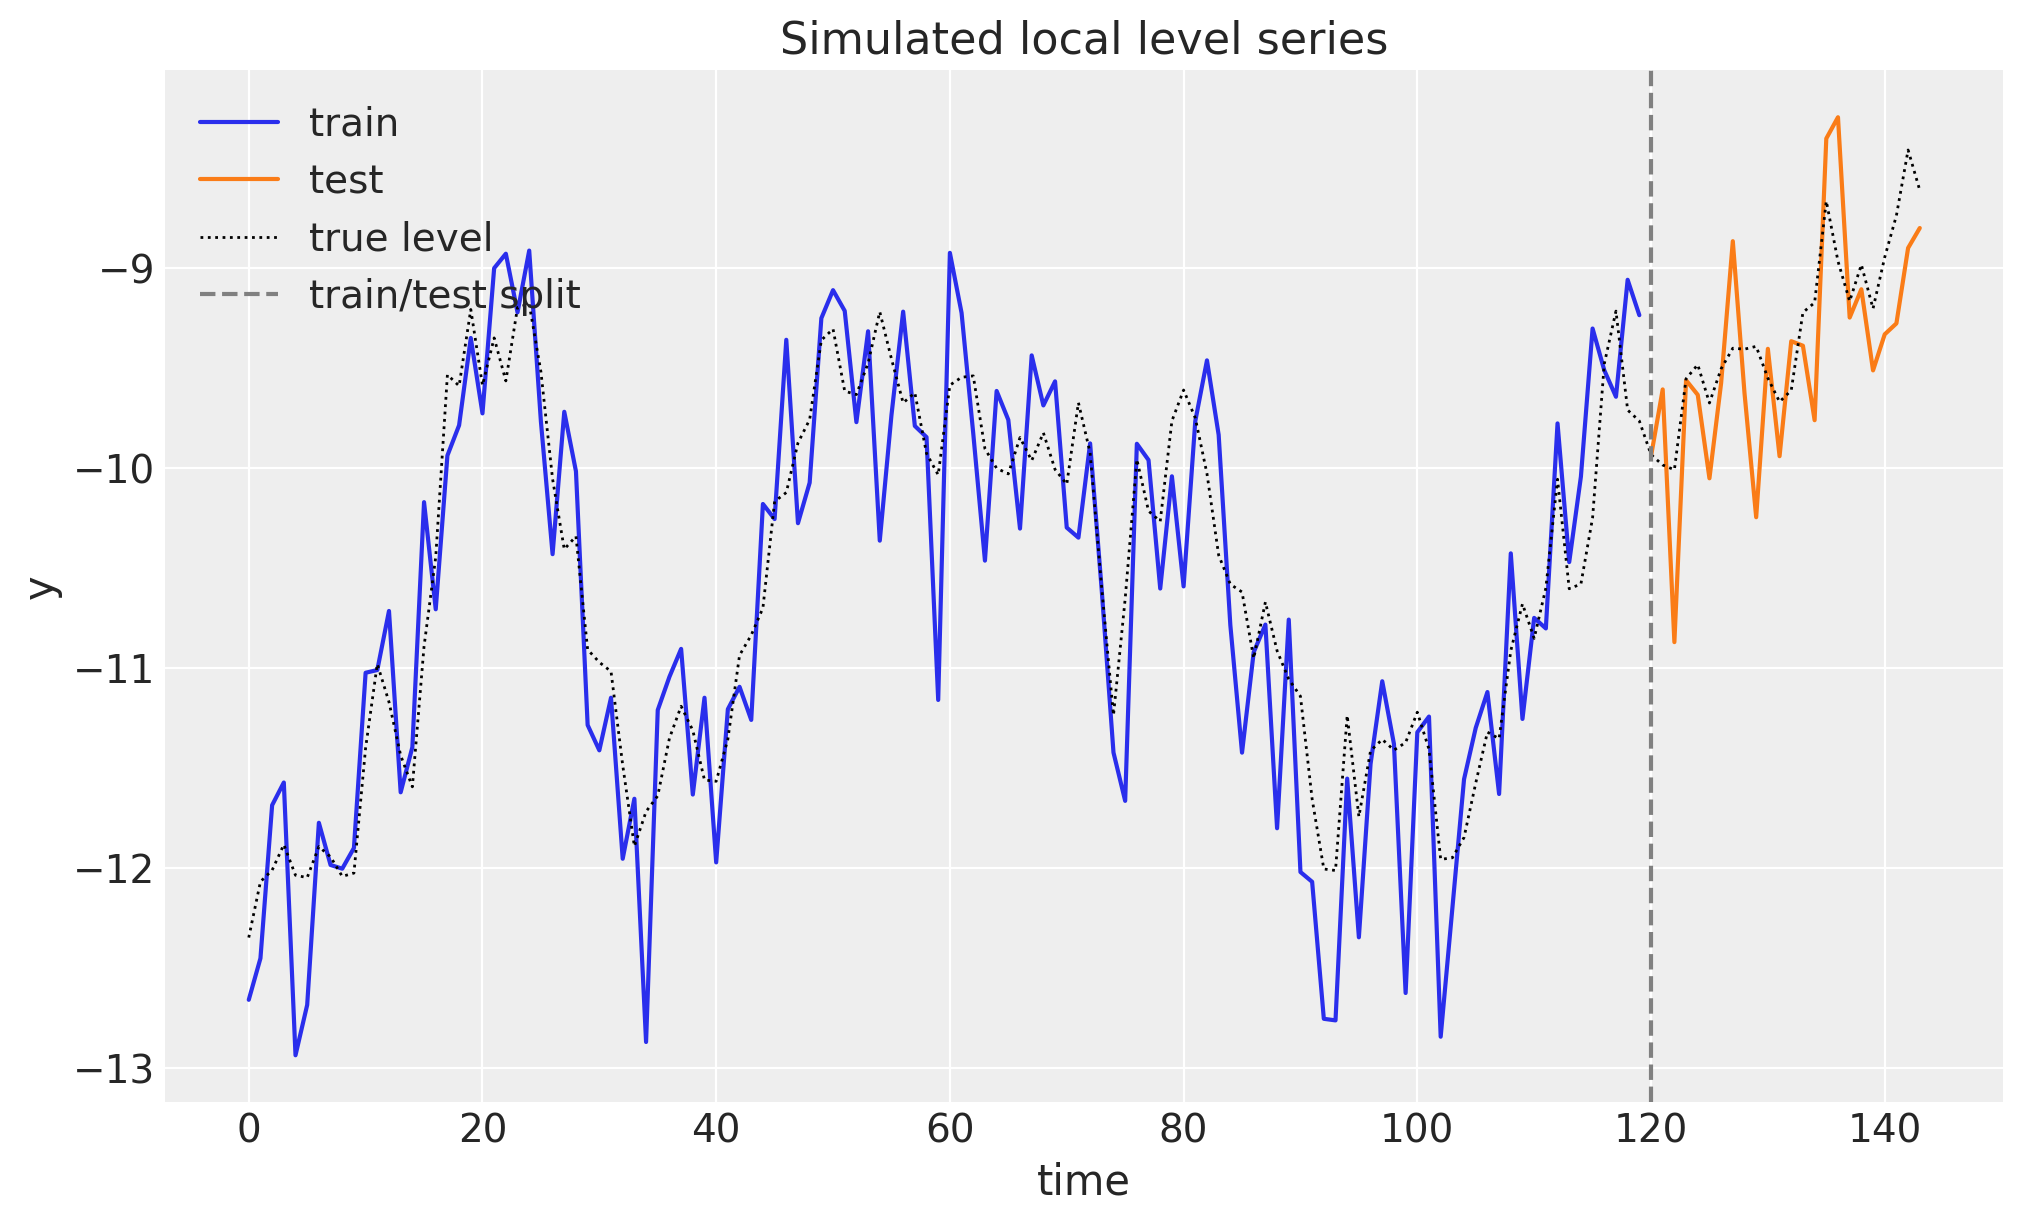

In [4]:
q_true, r_true = 0.3, 0.5
t_obs, future = 120, 24
duration = t_obs + future
time_index = np.arange(duration)
time_grid = np.arange(duration, dtype=np.float32)  # the block's default `times`

rng_key, rng_subkey = random.split(rng_key)
simulated = dsx.simulate(
    local_level_dynamics(jnp.asarray(q_true), jnp.asarray(r_true)),
    rng_key=rng_subkey,
    predict_times=jnp.asarray(time_grid),
)
assert simulated.observations is not None and simulated.states is not None  # raw simulation
y_full = simulated.observations[0]  # (duration, 1)
x_true = simulated.states[0, :, 0]  # (duration,)

train_data, test_data = y_full[:t_obs], y_full[t_obs:]
covariates_full = y_full  # the series doubles as the covariate
covariates_train = covariates_full[:t_obs]

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], train_data[:, 0], color="C0", label="train")
ax.plot(time_index[t_obs:], test_data[:, 0], color="C1", label="test")
ax.plot(time_index, x_true, color="black", lw=1, ls=":", label="true level")
ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated local level series", xlabel="time", ylabel="y");

### Prior predictive check

The priors on both scales are $\text{HalfNormal}(1)$, and the initial level is $\text{Normal}(0, 10)$. Before fitting anything we look at the series these priors generate. For a state space model the prior predictive is a forward simulation, so we write a tiny generative model in native `dynestyx` style (`dsx.sample` with `predict_times` only) and run it under a `Simulator` with NumPyro's `Predictive`. The prior paths cover the observed series comfortably without being absurdly wide.

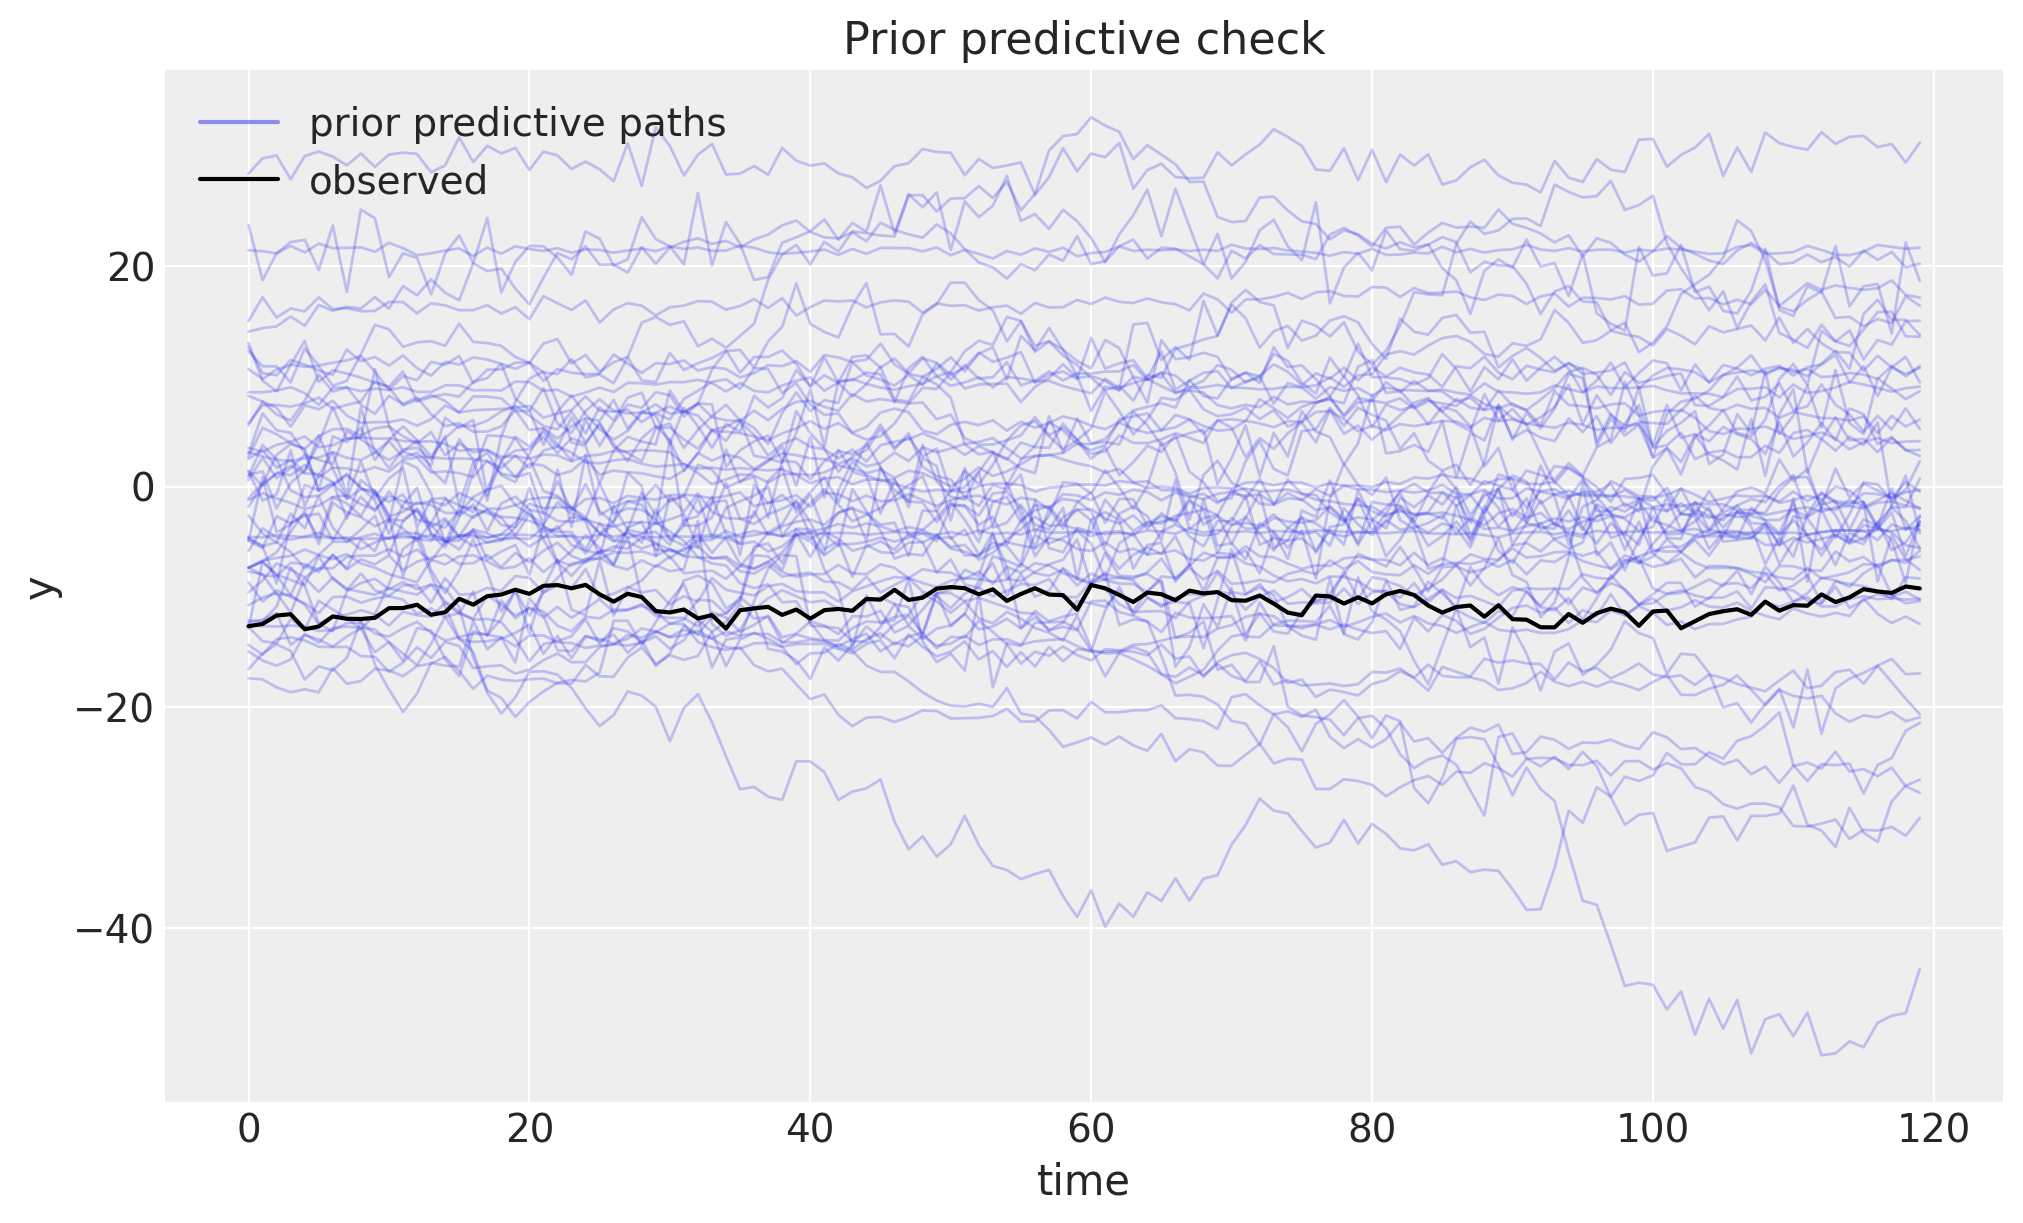

In [5]:
def local_level_prior(predict_times: Array) -> None:
    """Sample the scales from their priors and simulate a path from the local level model."""
    # jnp.asarray only narrows numpyro's union return type for the type checker.
    q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
    r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
    dsx.sample("f", local_level_dynamics(q, r), predict_times=predict_times)


rng_key, rng_subkey = random.split(rng_key)
with Simulator(n_simulations=1):
    prior_draws = Predictive(local_level_prior, num_samples=50, exclude_deterministic=False)(
        rng_subkey, predict_times=jnp.asarray(time_grid[:t_obs])
    )
prior_paths = np.asarray(prior_draws["f_observations"][:, 0, :, 0])  # (50, t_obs)

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], prior_paths.T, color="C0", alpha=0.25, lw=1)
ax.plot([], [], color="C0", alpha=0.5, label="prior predictive paths")
ax.plot(time_index[:t_obs], train_data[:, 0], color="black", lw=1.5, label="observed")
ax.legend(loc="upper left")
ax.set(title="Prior predictive check", xlabel="time", ylabel="y");

### The three models

All models are plain NumPyro functions `(covariates, data=None)` with the same priors and the same generative process; they differ only in how the latent level enters the trace.

The **direct** model is the idiomatic `numpyro_forecast` form: [`innovations`](https://juanitorduz.github.io/numpyro_forecast/reference/models.innovations.html) samples one innovation per time step (with a `LocScaleReparam` to soften the funnel between $q$ and the path), the level is their cumulative sum plus the initial level, and [`predict`](https://juanitorduz.github.io/numpyro_forecast/reference/models.predict.html) registers the likelihood. The sampler explores $t_{\text{obs}} + 3$ dimensions.

The two **`dynestyx`** models share one function of the conditioner. With a `LatentPathBuilder` the path is explicit (one sample site of shape $(t_{\text{obs}}, 1)$ plus the two scales); with a `Smoother` the Kalman smoother replaces the path by its exact integral, and the sampler explores $2$ dimensions. `KFSmootherConfig(filter_source="cd_dynamax")` is the exact Rauch-Tung-Striebel smoother on the cheapest backend for a short series on the CPU; `filter_source="cuthbert"` adds support for missing observations and time-varying parameters at a higher cost per gradient. The smoother is asked to record the smoothed means and variances, which we plot further down.

In [6]:
def local_level_direct(covariates: Array, data: Array | None = None) -> None:
    """Local level model with the innovations sampled explicitly."""
    h = Horizon.from_data(covariates, data)
    q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
    r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
    x0 = jnp.asarray(numpyro.sample("x0", dist.Normal(0.0, 10.0)))
    drift = innovations(h, "drift", lambda: dist.Normal(0.0, q), reparam=LocScaleReparam(0))
    level = x0 + jnp.cumsum(drift, axis=-2)
    predict(h, dist.Normal(0.0, r), level)


def local_level_state_space(conditioner: StateSpaceConditioner) -> ForecastModel:
    """Build the local level model conditioned by a dynestyx handler."""

    def model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        y = covariates[..., : h.t_obs, :]  # the observed window travels in the covariates
        q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
        r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
        result = state_space_series(h, "f", y, local_level_dynamics(q, r), conditioner=conditioner)
        if h.future > 0:
            numpyro.deterministic("forecast", result.y_future)
        elif h.data is None:
            numpyro.deterministic("obs", result.y_in_sample)

    return model


smoother = Smoother(
    smoother_config=KFSmootherConfig(
        filter_source="cd_dynamax",
        record_smoothed_states_mean=True,
        record_smoothed_states_cov_diag=True,
    )
)
local_level_latent = local_level_state_space(LatentPathBuilder())
local_level_smoothed = local_level_state_space(smoother)

### Fit with NUTS

We run the same sampler budget on the three models: $4$ chains of $1{,}000$ warmup and $1{,}000$ sampling steps. The `num_steps` extra field records the number of leapfrog steps, that is, gradient evaluations, which is what NUTS spends its time on. `mcmc.get_samples()` returns the flattened posterior dictionary that the package drivers consume; for the `dynestyx` models it also carries the deterministic sites their handlers record (`f_marginal_loglik`, `f_smoothed_states_mean`, `f_state_path`, ...).

In [7]:
def fit_nuts(
    rng_key: Array,
    model: ForecastModel,
    data: Array,
    covariates: Array,
    *,
    num_chains: int = 4,
    num_warmup: int = 1_000,
    num_samples: int = 1_000,
) -> tuple[MCMC, float]:
    """Fit ``model`` with NUTS and return the sampler and the wall time in seconds."""
    mcmc = MCMC(
        NUTS(model),
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains,
        chain_method="sequential",
        progress_bar=False,
    )
    start = time.perf_counter()
    mcmc.run(rng_key, covariates, data, extra_fields=("num_steps",))
    jax.block_until_ready(mcmc.get_samples())
    return mcmc, time.perf_counter() - start


models = {
    "direct (innovations)": local_level_direct,
    "dynestyx, explicit path": local_level_latent,
    "dynestyx, Kalman smoother": local_level_smoothed,
}
fits: dict[str, tuple[MCMC, float]] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    fits[label] = fit_nuts(rng_subkey, model, train_data, covariates_train)
    print(f"{label:>26}: {fits[label][1]:6.1f} s")
posteriors = {label: mcmc.get_samples() for label, (mcmc, _) in fits.items()}

      direct (innovations):   13.2 s


   dynestyx, explicit path:    8.3 s


 dynestyx, Kalman smoother:   12.6 s


### Compare the fits

The posteriors of the two scales agree with each other, as they must: the three models define the same joint distribution over $(q, r, y_{1:T})$, and the smoother integrates the level out exactly. All place the true values inside their bulk (with $120$ observations the scales are only moderately well identified, so a posterior mean one standard deviation away from the truth is expected). What differs is the work the sampler had to do. We collect the effective sample sizes and $\hat{R}$ with ArviZ (the `(chain, draw)` layout comes from `get_samples(group_by_chain=True)`) next to the wall time and the number of gradient evaluations.

In [8]:
def summarize_fit(mcmc: MCMC, label: str, wall: float) -> pd.DataFrame:
    """One-row table of posterior means, diagnostics and sampler cost for ``q`` and ``r``."""
    grouped = mcmc.get_samples(group_by_chain=True)
    tree = az.from_dict({"posterior": {name: np.asarray(grouped[name]) for name in ("q", "r")}})
    summary = az.summary(tree, var_names=["q", "r"])
    num_steps = int(np.asarray(mcmc.get_extra_fields(group_by_chain=True)["num_steps"]).sum())
    return pd.DataFrame(
        {
            "q mean": [summary.loc["q", "mean"]],
            "q sd": [summary.loc["q", "sd"]],
            "r mean": [summary.loc["r", "mean"]],
            "r sd": [summary.loc["r", "sd"]],
            "ess_bulk q": [summary.loc["q", "ess_bulk"]],
            "ess_bulk r": [summary.loc["r", "ess_bulk"]],
            "r_hat q": [summary.loc["q", "r_hat"]],
            "r_hat r": [summary.loc["r", "r_hat"]],
            "leapfrog steps": [num_steps],
            "wall time (s)": [wall],
        },
        index=[label],
    )


comparison = pd.concat([summarize_fit(mcmc, label, wall) for label, (mcmc, wall) in fits.items()])
print(f"truth: q = {q_true}, r = {r_true}")
comparison.round({"q mean": 3, "q sd": 3, "r mean": 3, "r sd": 3, "r_hat q": 3, "r_hat r": 3})

truth: q = 0.3, r = 0.5


,q mean,q sd,r mean,r sd,ess_bulk q,ess_bulk r,r_hat q,r_hat r,leapfrog steps,wall time (s)
direct (innovations),0.388,0.059,0.441,0.050,875.955108,798.614037,1.003,1.003,1019459,13.169452
"dynestyx, explicit path",0.389,0.064,0.441,0.054,593.486234,967.061397,1.010,1.006,65648,8.283533
"dynestyx, Kalman smoother",0.389,0.063,0.440,0.052,1525.787984,1699.750403,1.001,1.001,18062,12.635711


The smoothed model reaches the largest effective sample size with a small fraction of the gradient evaluations, because it moves in a two-dimensional posterior instead of a $123$-dimensional one whose geometry couples $q$ to every innovation. The explicit path built by `dynestyx` sits in between the two: it needs fewer gradients than the direct model but mixes less well on $q$, since its path site has no reparameterization equivalent to `LocScaleReparam` yet. Each smoother gradient is more expensive (a Kalman pass over the window instead of a sum of Gaussian log densities), so on a short series on the CPU the wall times end up in the same range; the advantage grows with the length of the series, since the direct posterior grows with it while the smoother's cost is linear in it and leaves the sampler's geometry untouched, and on accelerators, where the parallel-in-time scan of the `cuthbert` backend pays off.

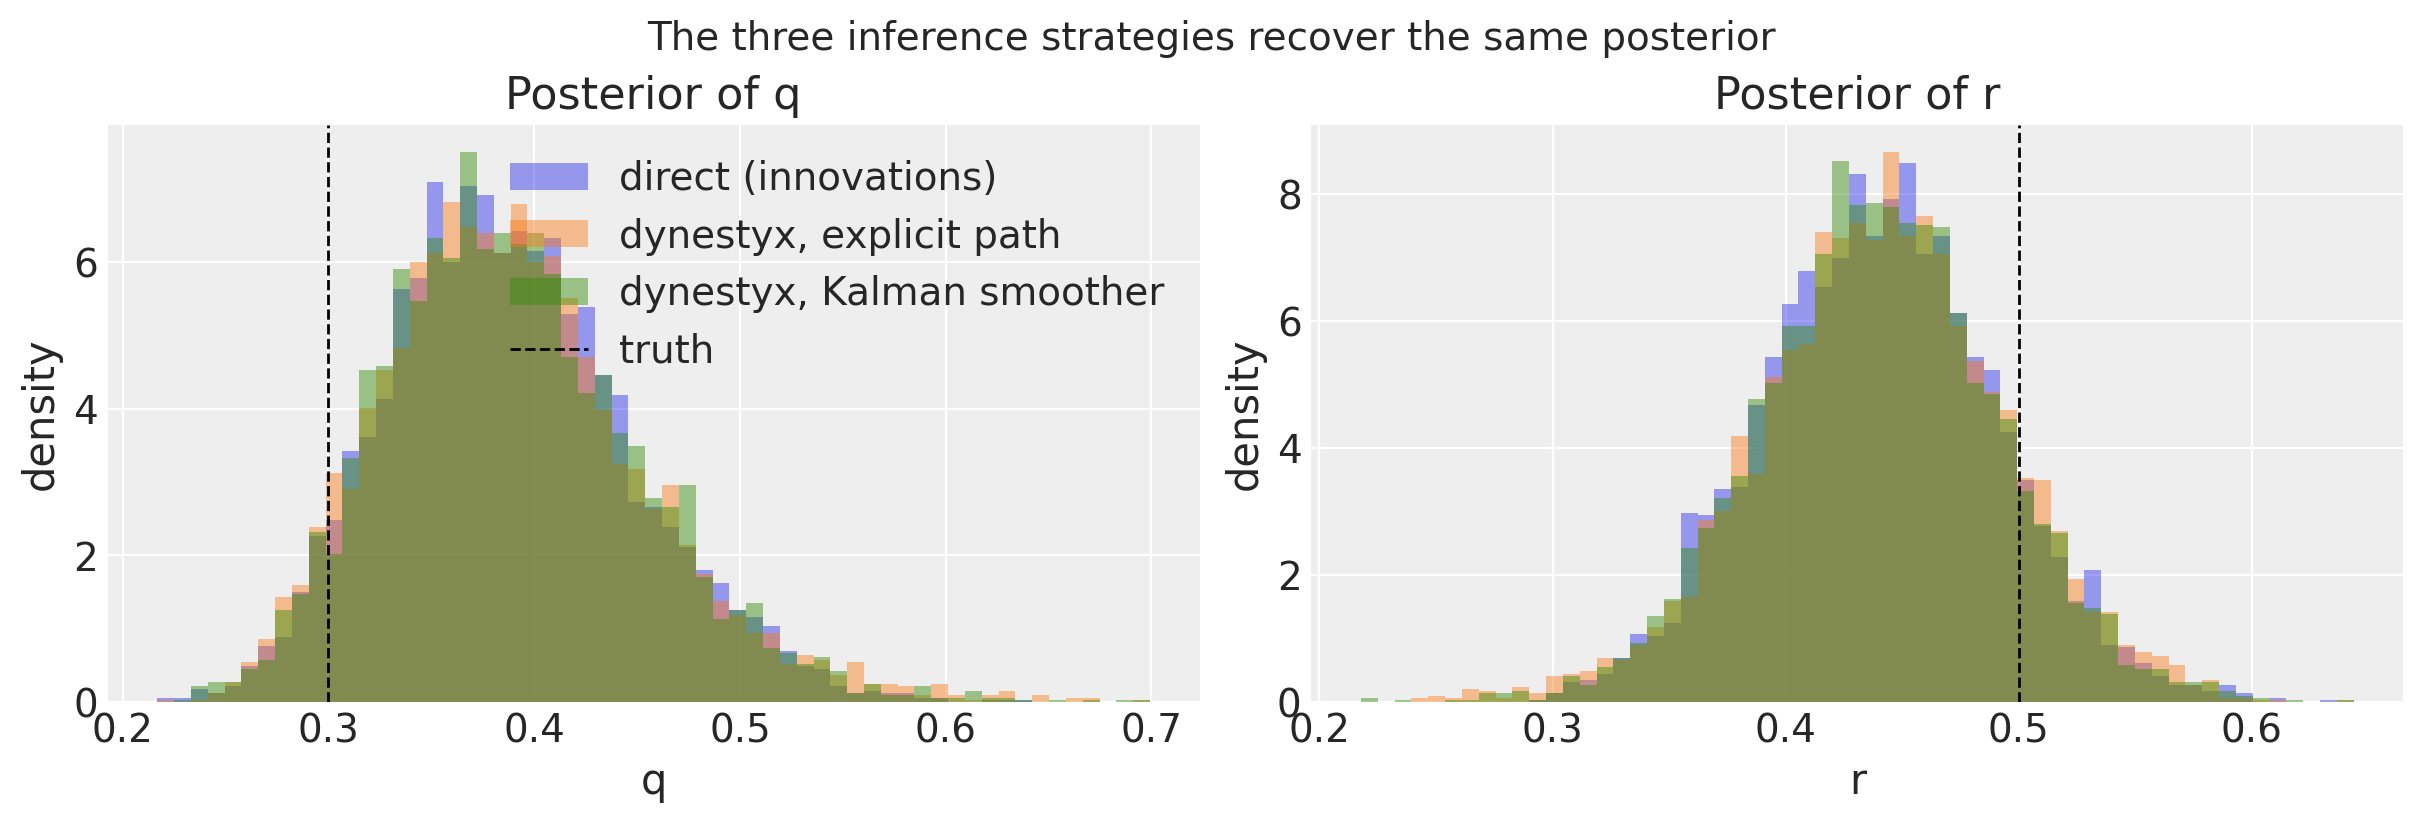

In [9]:
colors = {label: f"C{i}" for i, label in enumerate(models)}
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
for ax, name, truth in zip(axes, ("q", "r"), (q_true, r_true), strict=True):
    values = {label: np.asarray(post[name]) for label, post in posteriors.items()}
    bins = np.linspace(
        min(v.min() for v in values.values()), max(v.max() for v in values.values()), 60
    )
    for label, v in values.items():
        ax.hist(v, bins=bins, density=True, alpha=0.45, color=colors[label], label=label)
    ax.axvline(truth, color="black", ls="--", lw=1, label="truth")
    ax.set(title=f"Posterior of {name}", xlabel=name, ylabel="density")
axes[0].legend(loc="upper right")
fig.suptitle("The three inference strategies recover the same posterior", fontsize=14);

### Forecast

Forecasting is the package's [`forecast`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.forecast.html) driver in all three cases: it runs `Predictive` over the full-horizon covariates and returns the `"forecast"` site with one path per posterior draw. For the direct model the in-sample innovations are replayed from the posterior and the future ones are drawn from the prior; for the `dynestyx` models every draw re-conditions on the training window with its own $(q, r)$ (the smoother recomputes the smoothing distribution, the builder reconstructs the posterior path) and the simulator rolls the conditioned state forward. The driver is jitted and vectorized over the draws, and the `dynestyx` handlers inside the model run under that `jit` and `vmap` without any special treatment.

In [10]:
def hdi_over_draws(draws: Array | np.ndarray, prob: float) -> tuple[np.ndarray, np.ndarray]:
    """Lower and upper HDI bounds over the sample axis of ``(sample, time, 1)`` draws."""
    da = xr.DataArray(np.asarray(draws)[..., 0], dims=["sample", "time"])
    hdi = az.hdi(da, prob=prob, dim="sample")  # (time, ci_bound)
    return hdi.sel(ci_bound="lower").to_numpy(), hdi.sel(ci_bound="upper").to_numpy()


def hdi_label(prob: float, prefix: str = "") -> str:
    r"""Legend label for an HDI band, e.g. ``$94\%$ HDI``."""
    percent = f"{prob:.0%}".replace("%", r"\%")
    return f"{prefix}${percent}$ HDI"


hdi_probs = (0.5, 0.94)
hdi_alphas = {0.5: 0.6, 0.94: 0.3}  # 50% band darker, 94% band lighter

forecasts: dict[str, Array | np.ndarray] = {}
for label, model in models.items():
    rng_key, rng_subkey = random.split(rng_key)
    forecasts[label] = forecast(rng_subkey, model, posteriors[label], train_data, covariates_full)
    print(f"{label:>26}: forecast draws {forecasts[label].shape}")

      direct (innovations): forecast draws (4000, 24, 1)


   dynestyx, explicit path: forecast draws (4000, 24, 1)


 dynestyx, Kalman smoother: forecast draws (4000, 24, 1)


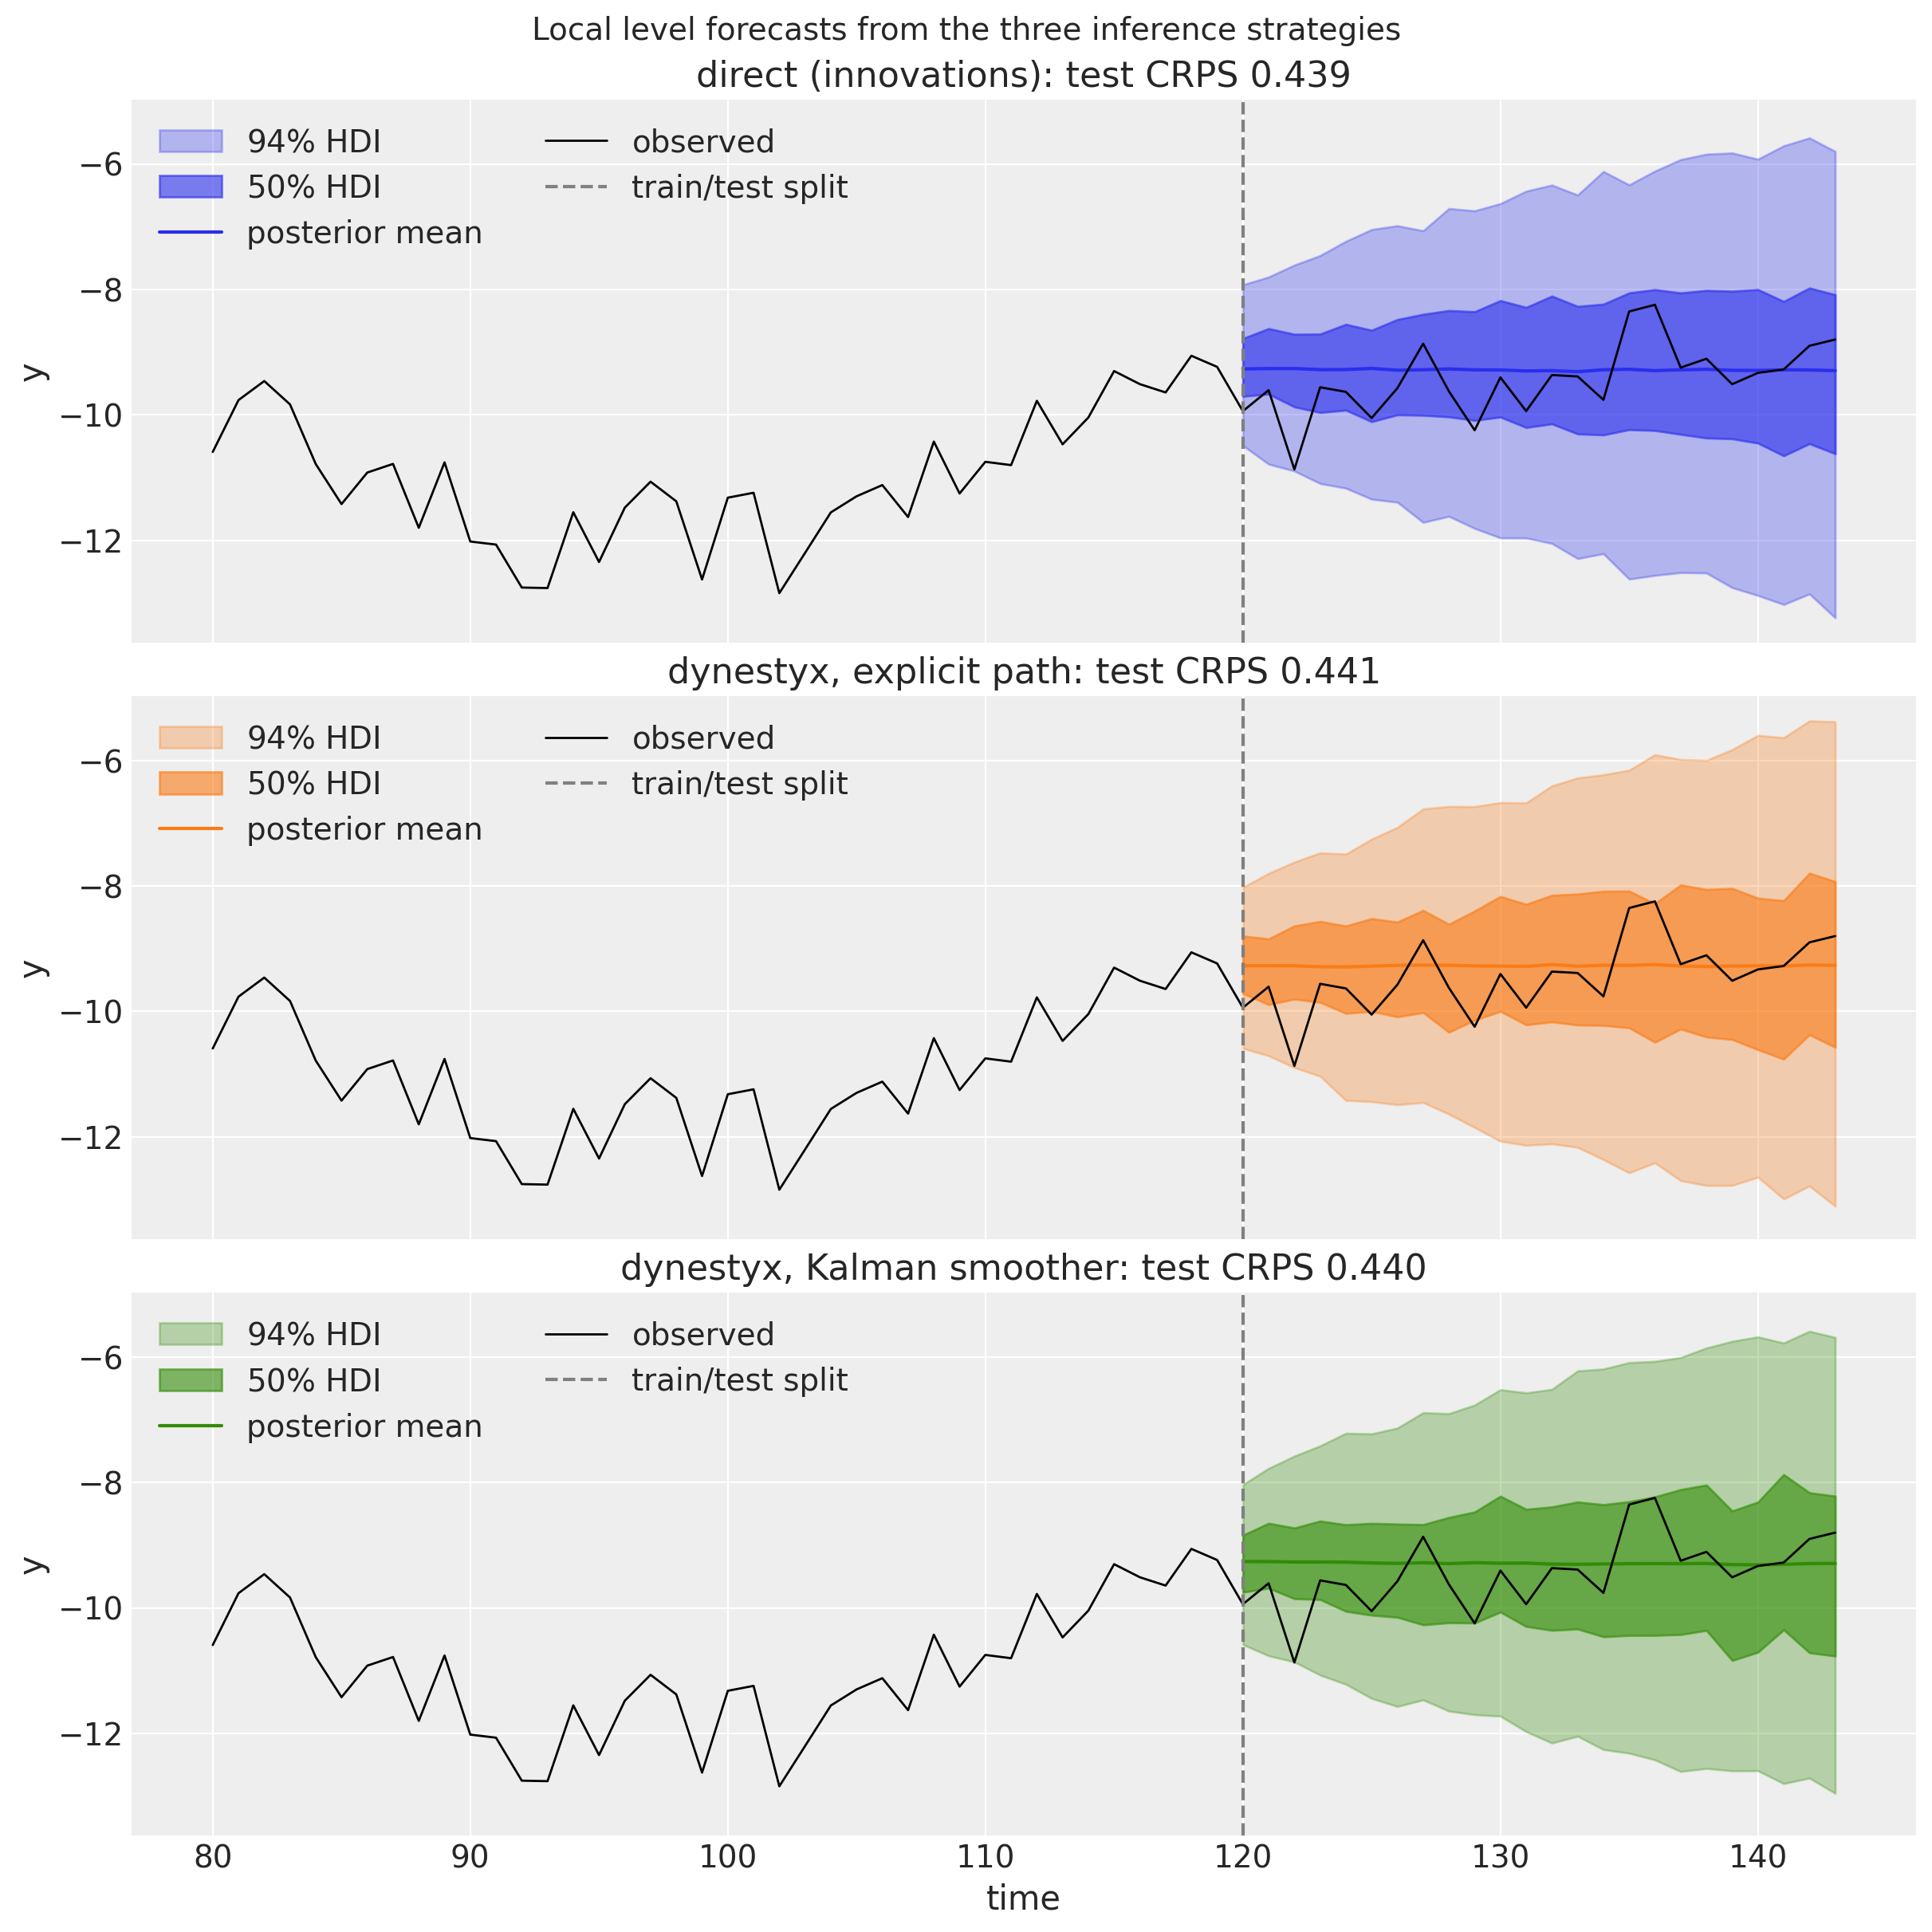

In [11]:
fig, axes = plt.subplots(
    nrows=3, ncols=1, figsize=(12, 12), sharex=True, sharey=True, layout="constrained"
)
future_index = time_index[t_obs:]
for ax, (label, draws) in zip(axes, forecasts.items(), strict=True):
    color = colors[label]
    for prob in sorted(hdi_probs, reverse=True):
        lower, upper = hdi_over_draws(draws, prob)
        ax.fill_between(
            future_index, lower, upper, color=color, alpha=hdi_alphas[prob], label=hdi_label(prob)
        )
    ax.plot(
        future_index, np.asarray(draws).mean(axis=0)[:, 0], color=color, label="posterior mean"
    )
    ax.plot(
        time_index[t_obs - 40 :], y_full[t_obs - 40 :, 0], color="black", lw=1, label="observed"
    )
    ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
    crps = eval_crps(draws, test_data)
    ax.set(title=f"{label}: test CRPS {crps:.3f}", ylabel="y")
    ax.legend(loc="upper left", ncol=2)
axes[-1].set(xlabel="time")
fig.suptitle("Local level forecasts from the three inference strategies", fontsize=14);

The three fans are the same forecast up to Monte Carlo error, which is the point of the exercise: the `dynestyx` models are not approximations of the direct one, they are the same model with a different parameterization for the sampler. The metrics on the held-out window agree accordingly (point accuracy through MAE and RMSE, the CRPS as a proper score for the whole predictive distribution, and the empirical coverage of the central $50\%$ and $94\%$ intervals).

In [12]:
metric_fns = {
    "MAE": eval_mae,
    "RMSE": eval_rmse,
    "CRPS": eval_crps,
    "coverage (50%)": partial(eval_coverage, alpha=0.5),
    "coverage (94%)": partial(eval_coverage, alpha=0.94),
}
pd.DataFrame(
    {
        label: {name: float(fn(draws, test_data)) for name, fn in metric_fns.items()}
        for label, draws in forecasts.items()
    }
).round(3)

,direct (innovations),"dynestyx, explicit path","dynestyx, Kalman smoother"
MAE,0.449,0.449,0.447
RMSE,0.591,0.586,0.591
CRPS,0.439,0.441,0.440
coverage (50%),0.833,0.833,0.833
coverage (94%),1.000,1.000,1.000


### In-sample fit

Because the observed window travels in the covariates, the package's [`to_datatree`](https://juanitorduz.github.io/numpyro_forecast/reference/convert.to_datatree.html) applies to the `dynestyx` models as it does to any other: it restores the `(chain, draw)` structure, samples the in-sample posterior predictive by calling the model without data, and, because we hand it the full-horizon covariates, runs the forecast into the `predictions` group. For the direct model the in-sample predictive replays the sampled path and adds observation noise; for the smoothed model the block draws every in-window state from the smoothing distribution $p(x_t \mid y_{1:T}, \theta)$ and adds the same noise, which is the same quantity marginally at every step. The two bands coincide.

In [13]:
trees: dict[str, xr.DataTree] = {}
for label in ("direct (innovations)", "dynestyx, Kalman smoother"):
    rng_key, rng_subkey = random.split(rng_key)
    trees[label] = to_datatree(
        rng_subkey, models[label], posteriors[label], train_data, covariates_full, num_chains=4
    )
trees["dynestyx, Kalman smoother"]

<xarray.DataTree>
Group: /
│   Attributes:
│       inference_library:  numpyro
│       creation_library:   numpyro_forecast
│       sample_dims:        ['chain', 'draw']
├── Group: /posterior
│       Dimensions:                           (chain: 4, draw: 1000,
│                                              f_smoothed_states_cov_dim_0: 120,
│                                              f_smoothed_states_cov_dim_1: 1,
│                                              f_smoothed_states_cov_dim_2: 1,
│                                              f_smoothed_states_cov_diag_dim_0: 120,
│                                              f_smoothed_states_cov_diag_dim_1: 1,
│                                              f_smoothed_states_mean_dim_0: 120,
│                                              f_smoothed_states_mean_dim_1: 1)
│       Coordinates:
│         * chain                             (chain) int64 32B 0 1 2 3
│         * draw                              (draw) int64 8kB 0 1 2 3 ... 997 998 999
│         * f_smoothed_states_cov_dim_0       (f_smoothed_states_cov_dim_0) int64 960B ...
│         * f_smoothed_states_cov_dim_1       (f_smoothed_states_cov_dim_1) int64 8B 0
│         * f_smoothed_states_cov_dim_2       (f_smoothed_states_cov_dim_2) int64 8B 0
│         * f_smoothed_states_cov_diag_dim_0  (f_smoothed_states_cov_diag_dim_0) int64 960B ...
│         * f_smoothed_states_cov_diag_dim_1  (f_smoothed_states_cov_diag_dim_1) int64 8B ...
│         * f_smoothed_states_mean_dim_0      (f_smoothed_states_mean_dim_0) int64 960B ...
│         * f_smoothed_states_mean_dim_1      (f_smoothed_states_mean_dim_1) int64 8B 0
│       Data variables:
│           f_marginal_loglik                 (chain, draw) float32 16kB -125.2 ... -...
│           f_smoothed_states_cov             (chain, draw, f_smoothed_states_cov_dim_0, f_smoothed_states_cov_dim_1, f_smoothed_states_cov_dim_2) float32 2MB ...
│           f_smoothed_states_cov_diag        (chain, draw, f_smoothed_states_cov_diag_dim_0, f_smoothed_states_cov_diag_dim_1) float32 2MB ...
│           f_smoothed_states_mean            (chain, draw, f_smoothed_states_mean_dim_0, f_smoothed_states_mean_dim_1) float32 2MB ...
│           q                                 (chain, draw) float32 16kB 0.3989 ... 0...
│           r                                 (chain, draw) float32 16kB 0.3879 ... 0...
│       Attributes:
│           created_at:                 2026-09-13T18:27:33.954527+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /posterior_predictive
│       Dimensions:  (chain: 4, draw: 1000, time: 120, obs_dim: 1)
│       Coordinates:
│         * chain    (chain) int64 32B 0 1 2 3
│         * draw     (draw) int64 8kB 0 1 2 3 4 5 6 7 ... 993 994 995 996 997 998 999
│         * time     (time) int64 960B 0 1 2 3 4 5 6 7 ... 113 114 115 116 117 118 119
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (chain, draw, time, obs_dim) float32 2MB -12.81 -11.43 ... -8.829
│       Attributes:
│           created_at:                 2026-09-13T18:27:34.512600+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_library_language:  Python
│           sample_dims:                ['chain', 'draw']
├── Group: /observed_data
│       Dimensions:  (time: 120, obs_dim: 1)
│       Coordinates:
│         * time     (time) int64 960B 0 1 2 3 4 5 6 7 ... 113 114 115 116 117 118 119
│         * obs_dim  (obs_dim) int64 8B 0
│       Data variables:
│           obs      (time, obs_dim) float32 480B -12.66 -12.45 -11.69 ... -9.059 -9.236
│       Attributes:
│           created_at:                 2026-09-13T18:27:34.512884+00:00
│           creation_library:           ArviZ
│           creation_library_version:   1.3.0
│           creation_libra

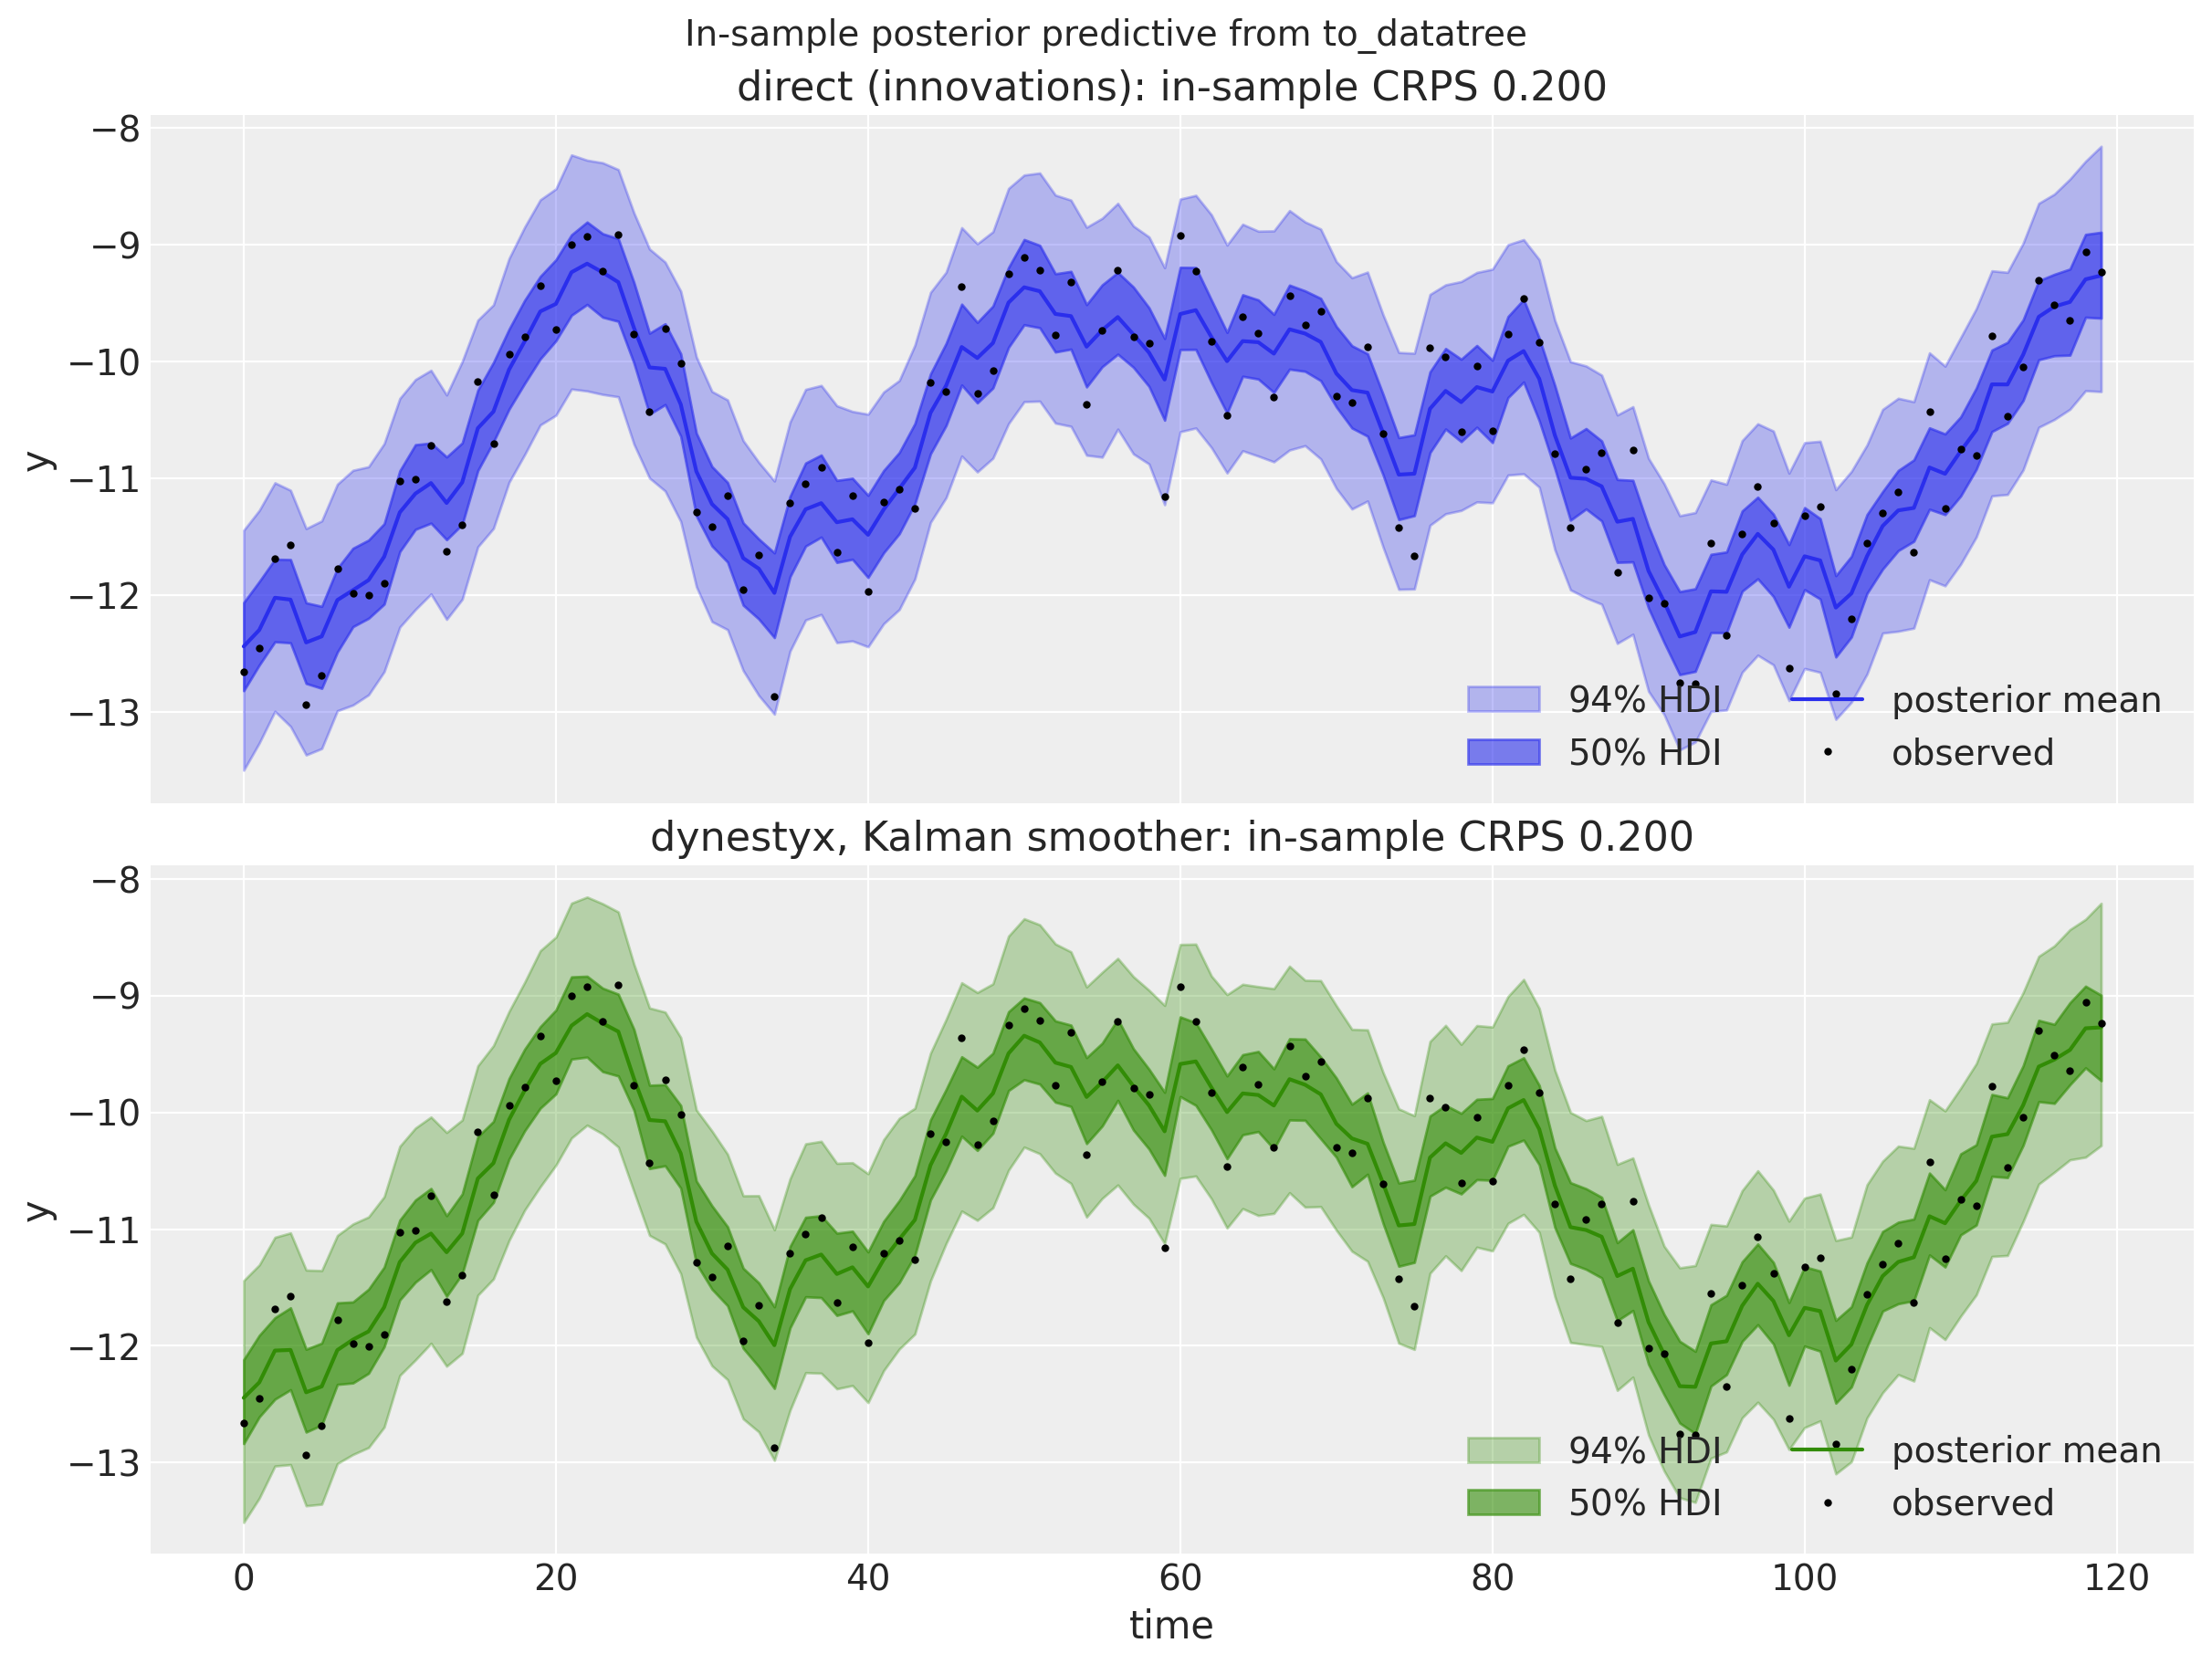

In [14]:
def stacked_draws(tree: xr.DataTree, group: str, var: str) -> np.ndarray:
    """Stack the ``(chain, draw)`` dims of ``tree[group][var]`` into a leading sample axis."""
    return (
        tree[group]
        .dataset[var]
        .stack(sample=("chain", "draw"))
        .transpose("sample", "time", "obs_dim")
        .to_numpy()
    )


fig, axes = plt.subplots(
    nrows=2, ncols=1, figsize=(12, 9), sharex=True, sharey=True, layout="constrained"
)
for ax, (label, tree) in zip(axes, trees.items(), strict=True):
    in_sample = stacked_draws(tree, "posterior_predictive", "obs")
    color = colors[label]
    for prob in sorted(hdi_probs, reverse=True):
        lower, upper = hdi_over_draws(in_sample, prob)
        ax.fill_between(
            time_index[:t_obs],
            lower,
            upper,
            color=color,
            alpha=hdi_alphas[prob],
            label=hdi_label(prob),
        )
    ax.plot(time_index[:t_obs], in_sample.mean(axis=0)[:, 0], color=color, label="posterior mean")
    ax.plot(time_index[:t_obs], train_data[:, 0], ".", color="black", ms=4, label="observed")
    crps = eval_crps(in_sample, train_data)
    ax.set(title=f"{label}: in-sample CRPS {crps:.3f}", ylabel="y")
    ax.legend(loc="lower right", ncol=2)
axes[-1].set(xlabel="time")
fig.suptitle("In-sample posterior predictive from to_datatree", fontsize=14);

The smoothing distribution is what makes this possible, and it is worth seeing why a `Filter` cannot serve the same purpose. The filtering distribution $p(x_t \mid y_{1:t}, \theta)$ uses the observations up to step $t$ only, so it lags the level and is wider at the start of the window, where little has been seen; the smoothing distribution $p(x_t \mid y_{1:T}, \theta)$ uses the whole window. `dynestyx` lets us look at both from the same posterior: the smoother recorded its means and variances as the `f_smoothed_states_*` sites during the fit, and re-interpreting the same model under a `Filter` conditioner with `Predictive` records the `f_filtered_states_*` sites without any refitting, which is the separation between model and inference that the handlers are designed for. Drawing one level per posterior draw from each Gaussian mixes the state uncertainty and the parameter uncertainty into a single band.

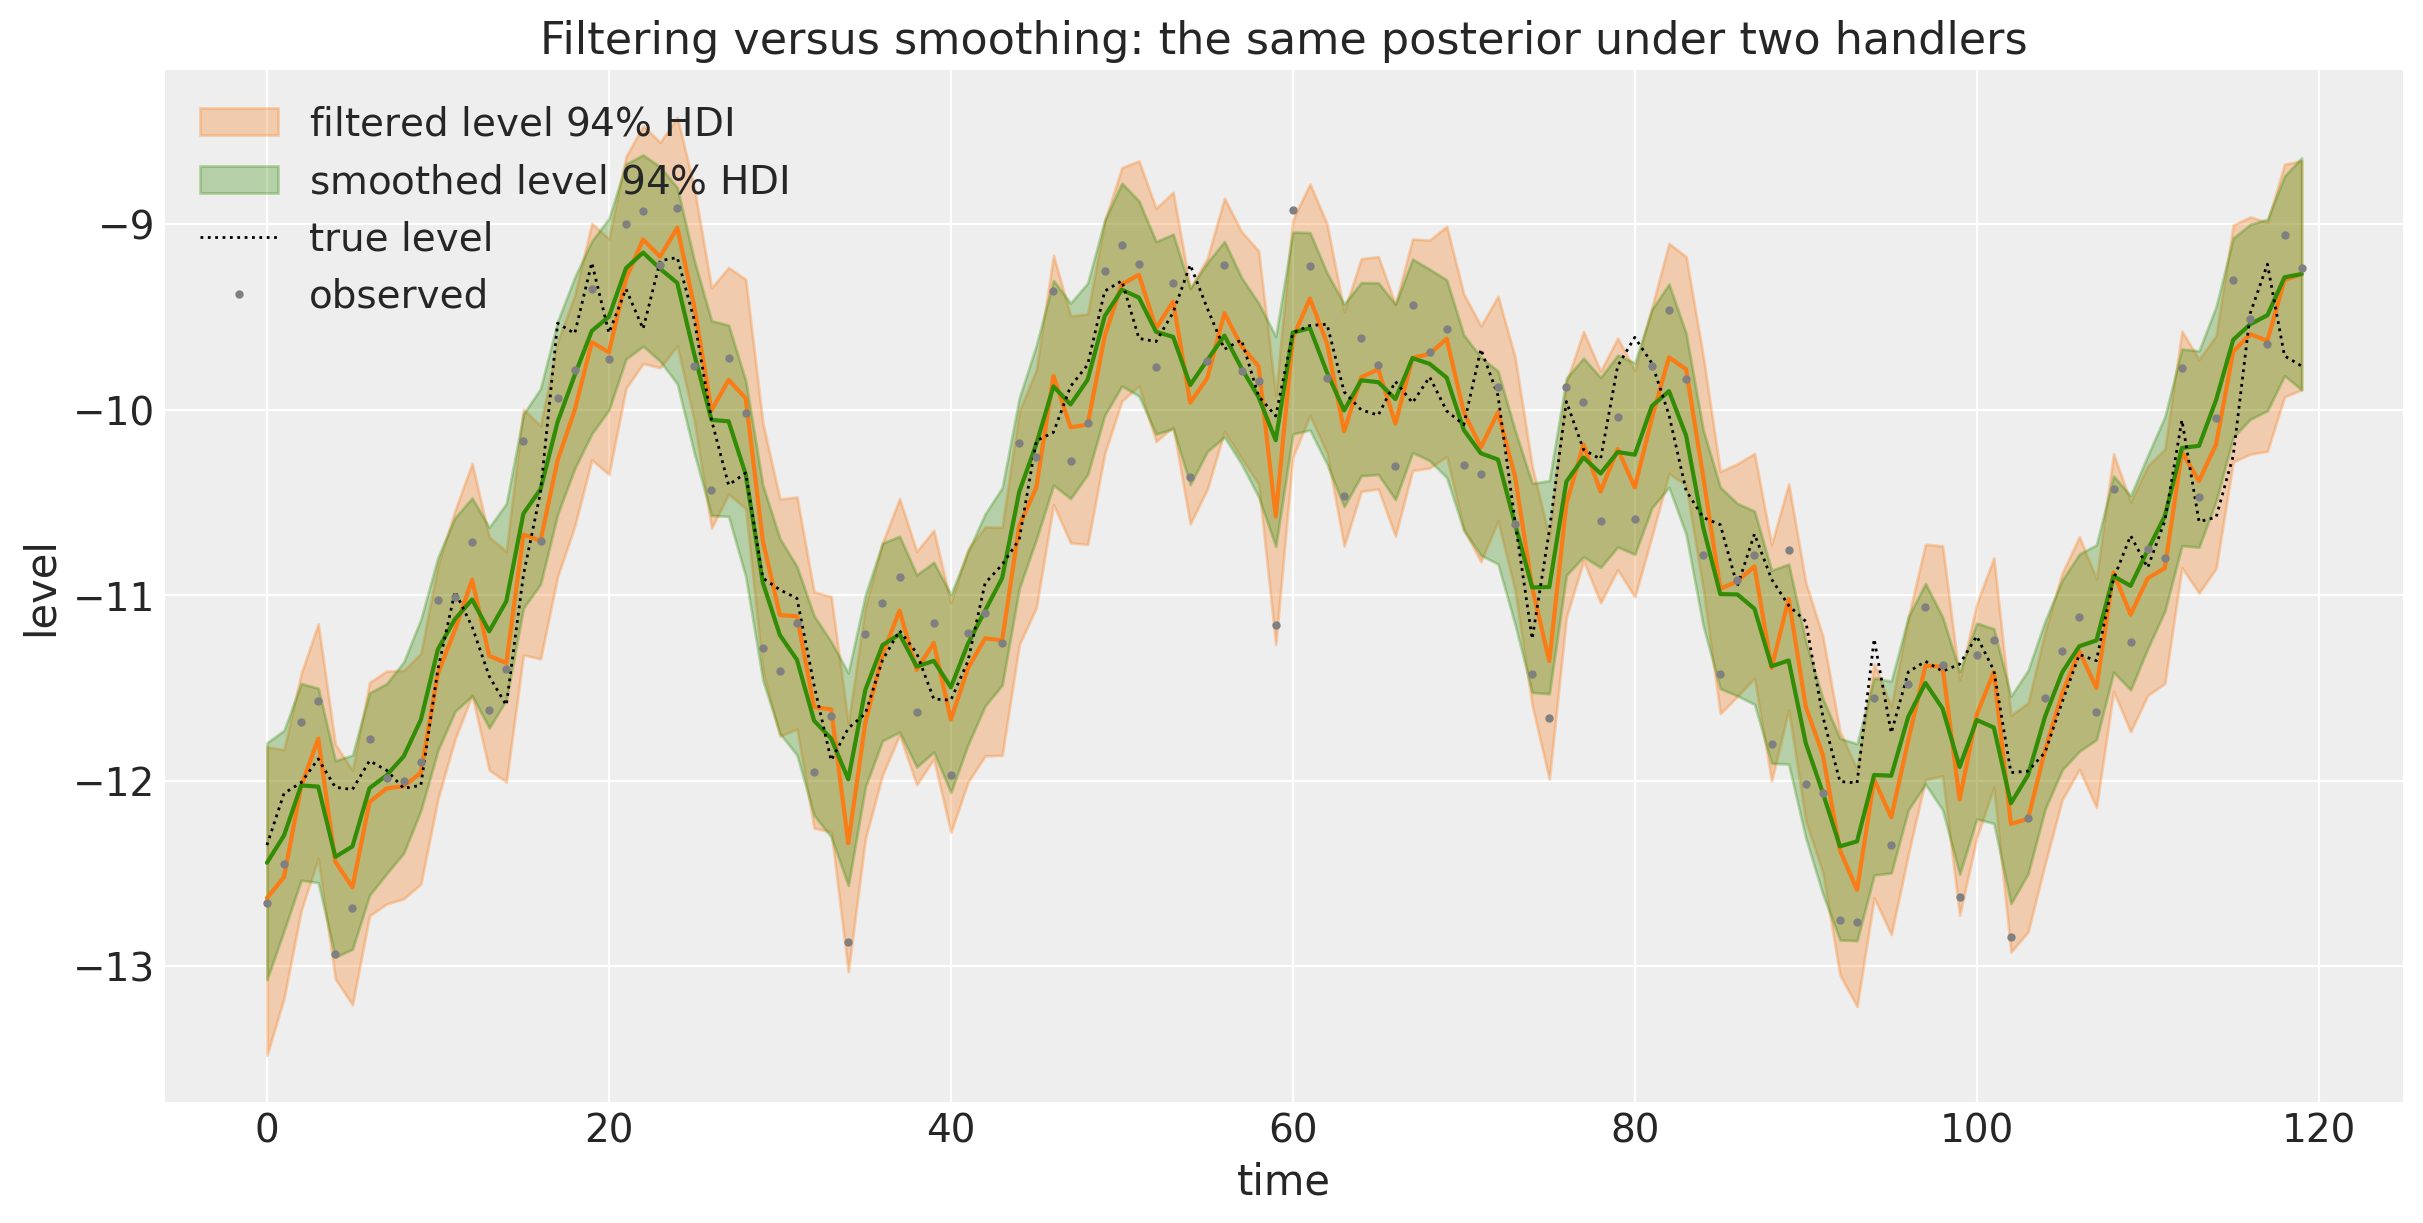

In [15]:
posterior_smoothed = posteriors["dynestyx, Kalman smoother"]
local_level_filtered = local_level_state_space(Filter(filter_config=KFConfig()))
rng_key, rng_subkey = random.split(rng_key)
filtered_sites = Predictive(
    local_level_filtered,
    posterior_samples=posterior_smoothed,
    return_sites=["f_filtered_states_mean", "f_filtered_states_cov_diag"],
)(rng_subkey, covariates_train, train_data)


def level_draws(rng_key: Array, mean: Array | np.ndarray, var: Array | np.ndarray) -> np.ndarray:
    """One level per posterior draw from the per-step Gaussians ``Normal(mean, sqrt(var))``."""
    mean, var = np.asarray(mean), np.asarray(var)
    return mean + np.sqrt(var) * np.asarray(random.normal(rng_key, mean.shape))


rng_key, key_filtered, key_smoothed = random.split(rng_key, 3)
levels = {
    "filtered level": level_draws(
        key_filtered,
        filtered_sites["f_filtered_states_mean"],
        filtered_sites["f_filtered_states_cov_diag"],
    ),
    "smoothed level": level_draws(
        key_smoothed,
        posterior_smoothed["f_smoothed_states_mean"],
        posterior_smoothed["f_smoothed_states_cov_diag"],
    ),
}

fig, ax = plt.subplots(figsize=(12, 6))
for (label, draws), color in zip(levels.items(), ("C1", "C2"), strict=True):
    lower, upper = hdi_over_draws(draws, 0.94)
    ax.fill_between(
        time_index[:t_obs],
        lower,
        upper,
        color=color,
        alpha=0.3,
        label=hdi_label(0.94, prefix=f"{label} "),
    )
    ax.plot(time_index[:t_obs], draws.mean(axis=0)[:, 0], color=color, lw=1.5)
ax.plot(time_index[:t_obs], x_true[:t_obs], color="black", lw=1, ls=":", label="true level")
ax.plot(time_index[:t_obs], train_data[:, 0], ".", color="gray", ms=4, label="observed")
ax.legend(loc="upper left")
ax.set(
    title="Filtering versus smoothing: the same posterior under two handlers",
    xlabel="time",
    ylabel="level",
);

## Example 2: seasonal regression through the covariates

The package routes everything a model needs at prediction time through the `covariates` array, which spans the full horizon. In this example the array carries two things: the observed series in its first column, which the model reads back as the observed window, and Fourier features in the remaining columns, which the block forwards to `dynestyx` as control inputs (`ctrl_values`) on a time grid that covers both the observed and the predicted steps. The seasonal pattern enters the observation equation as a regression on those features with coefficients $\beta$, so with $u_t$ the row of features at step $t$:

$$
\begin{align*}
x_t &= x_{t-1} + w_t, \qquad w_t \sim \text{Normal}(0, q), \\
y_t &= x_t + \beta^\top u_t + v_t, \qquad v_t \sim \text{Normal}(0, r).
\end{align*}
$$

In `dynestyx` terms $\beta^\top u_t$ is the `D` matrix of `LTI_discrete`, which infers the control dimension from it since [dynestyx#361](https://github.com/BasisResearch/dynestyx/pull/361) (on `dynestyx` 0.5.0, build the `DynamicalModel` explicitly with `control_dim=beta.shape[-1]`).

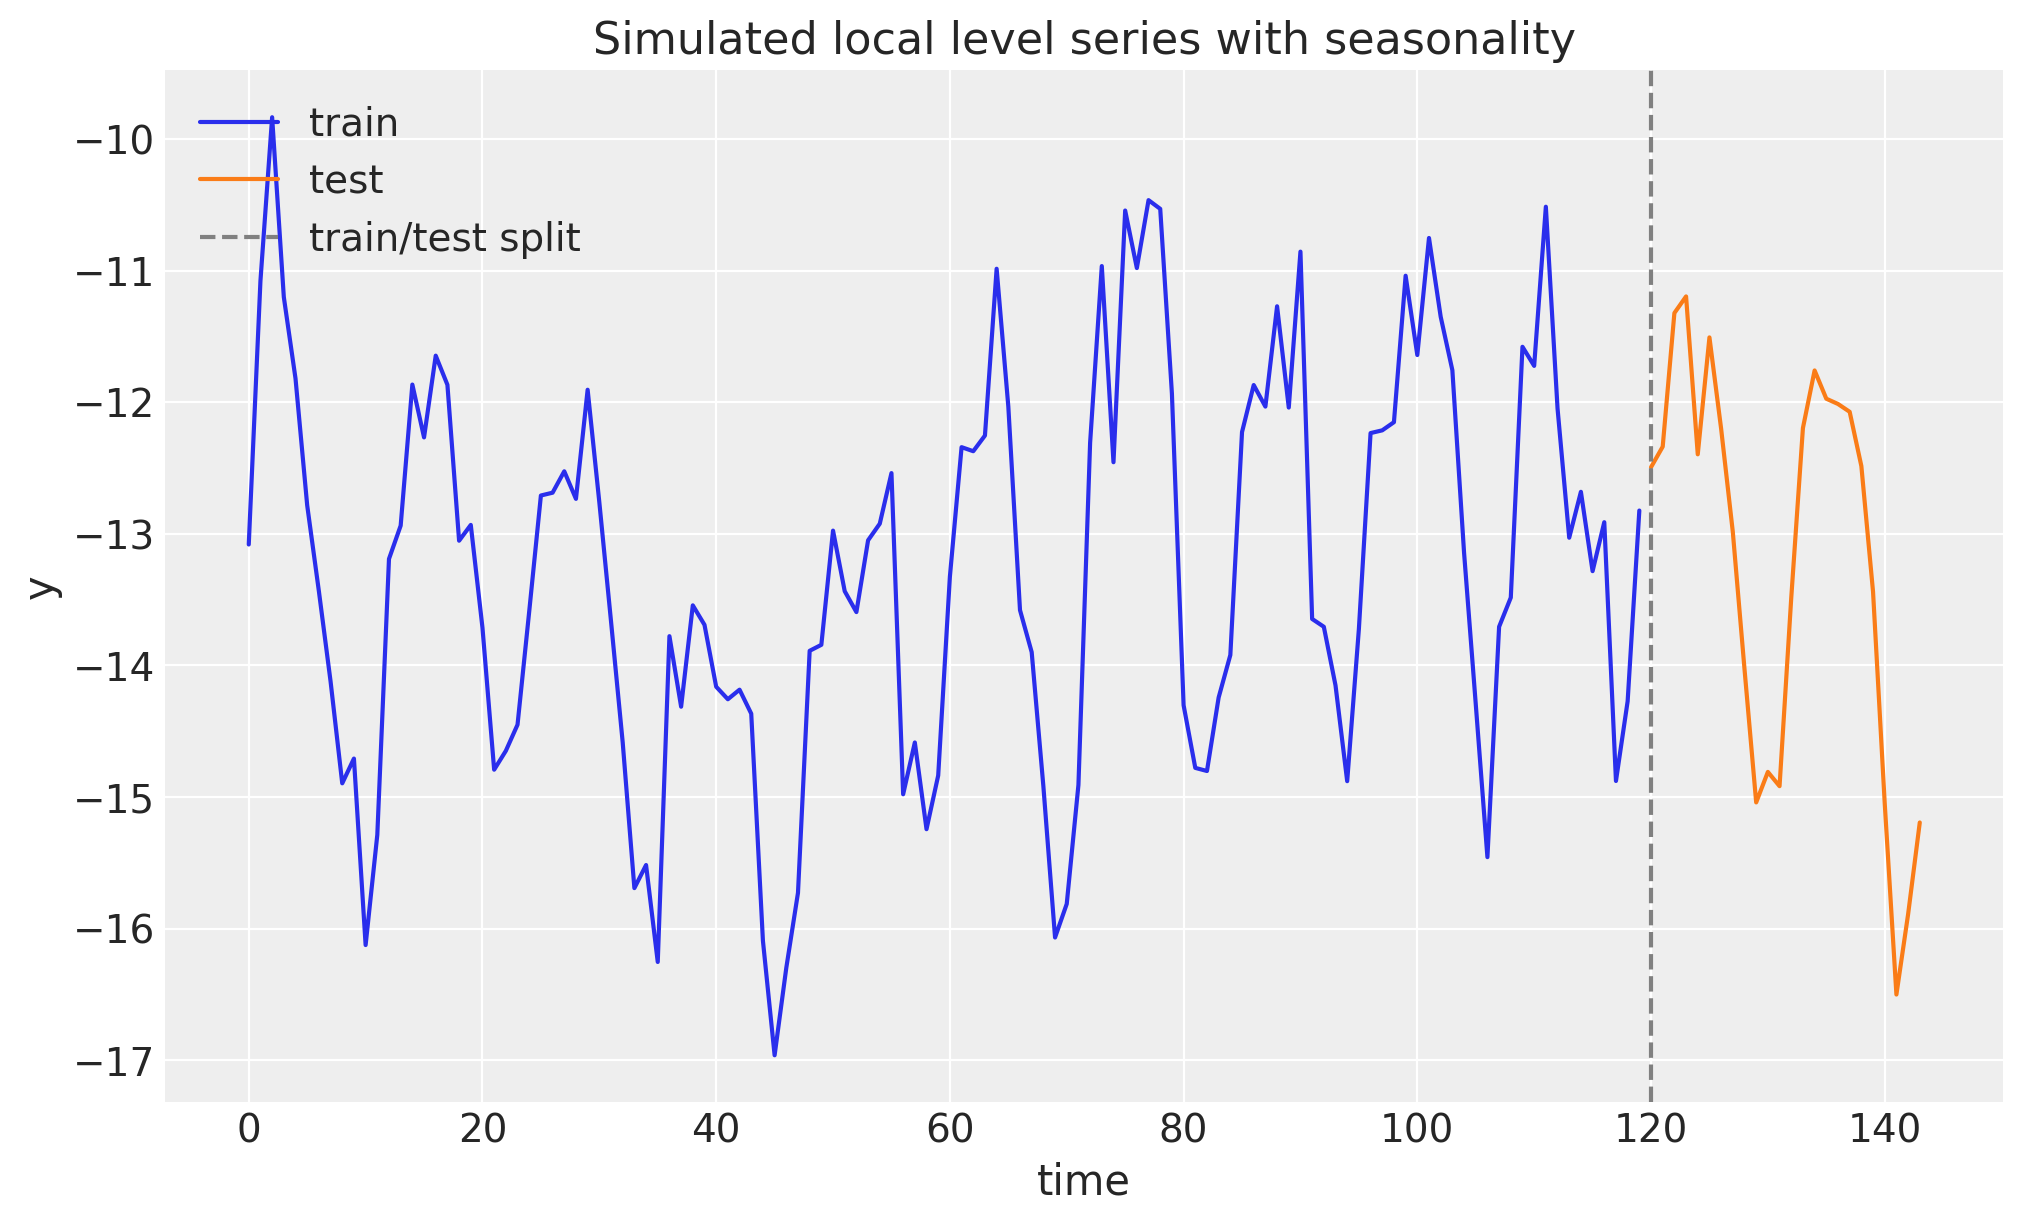

In [16]:
period, num_terms = 12.0, 2
beta_true = jnp.array([1.5, 0.5, -0.4, 0.3])
features_full = fourier_features(duration, period=period, num_terms=num_terms)  # (duration, 4)


def seasonal_level_dynamics(q: Array, r: Array, beta: Array) -> DynamicalModel:
    """Local level dynamics with a regression on the controls in the observation equation."""
    return dsx.LTI_discrete(
        A=jnp.eye(1),
        Q=jnp.eye(1) * q**2,
        H=jnp.eye(1),
        R=jnp.eye(1) * r**2,
        D=beta[None, :],
        initial_mean=jnp.zeros(1),
        initial_cov=jnp.eye(1) * 100.0,
    )


rng_key, rng_subkey = random.split(rng_key)
simulated_seasonal = dsx.simulate(
    seasonal_level_dynamics(jnp.asarray(q_true), jnp.asarray(r_true), beta_true),
    rng_key=rng_subkey,
    ctrl_times=jnp.asarray(time_grid),
    ctrl_values=features_full,
    predict_times=jnp.asarray(time_grid),
)
assert simulated_seasonal.observations is not None  # raw simulation
y_seasonal = simulated_seasonal.observations[0]  # (duration, 1)
train_seasonal, test_seasonal = y_seasonal[:t_obs], y_seasonal[t_obs:]
covariates_seasonal = jnp.concatenate([y_seasonal, features_full], axis=-1)  # (duration, 5)
covariates_seasonal_train = covariates_seasonal[:t_obs]

fig, ax = plt.subplots()
ax.plot(time_index[:t_obs], train_seasonal[:, 0], color="C0", label="train")
ax.plot(time_index[t_obs:], test_seasonal[:, 0], color="C1", label="test")
ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Simulated local level series with seasonality", xlabel="time", ylabel="y");

The model splits the covariate array into the observed window and the controls, adds a $\text{Normal}(0, 1)$ prior on the four coefficients, and conditions with the same smoother as before.

In [17]:
def seasonal_level_state_space(conditioner: StateSpaceConditioner) -> ForecastModel:
    """Build the local level plus seasonal regression model conditioned by a dynestyx handler."""

    def model(covariates: Array, data: Array | None = None) -> None:
        h = Horizon.from_data(covariates, data)
        y = covariates[..., : h.t_obs, :1]  # the observed series is the first column
        controls = covariates[..., 1:]  # the Fourier features span the full horizon
        q = jnp.asarray(numpyro.sample("q", dist.HalfNormal(1.0)))
        r = jnp.asarray(numpyro.sample("r", dist.HalfNormal(1.0)))
        beta = jnp.asarray(
            numpyro.sample("beta", dist.Normal(0.0, 1.0).expand([controls.shape[-1]]).to_event(1))
        )
        result = state_space_series(
            h,
            "f",
            y,
            seasonal_level_dynamics(q, r, beta),
            conditioner=conditioner,
            controls=controls,
        )
        if h.future > 0:
            numpyro.deterministic("forecast", result.y_future)
        elif h.data is None:
            numpyro.deterministic("obs", result.y_in_sample)

    return model


seasonal_level_smoothed = seasonal_level_state_space(
    Smoother(smoother_config=KFSmootherConfig(filter_source="cd_dynamax"))
)

### Fit with SVI

Variational inference is the other standard path in the package and it works on the smoothed model unchanged: `AutoNormal` puts a mean-field Gaussian on the six unconstrained parameters and `Trace_ELBO` includes the smoother's factor. Because the level is integrated out, the guide never has to approximate a $t_{\text{obs}}$-dimensional latent path, which is where mean-field guides usually underestimate uncertainty. We draw the posterior with [`draw_posterior`](https://juanitorduz.github.io/numpyro_forecast/reference/predictive.draw_posterior.html) and forecast as before.

SVI: 2.9 s, final loss 145.99
posterior mean of beta: [ 1.54  0.31 -0.46  0.28]
truth:                  [ 1.5  0.5 -0.4  0.3]


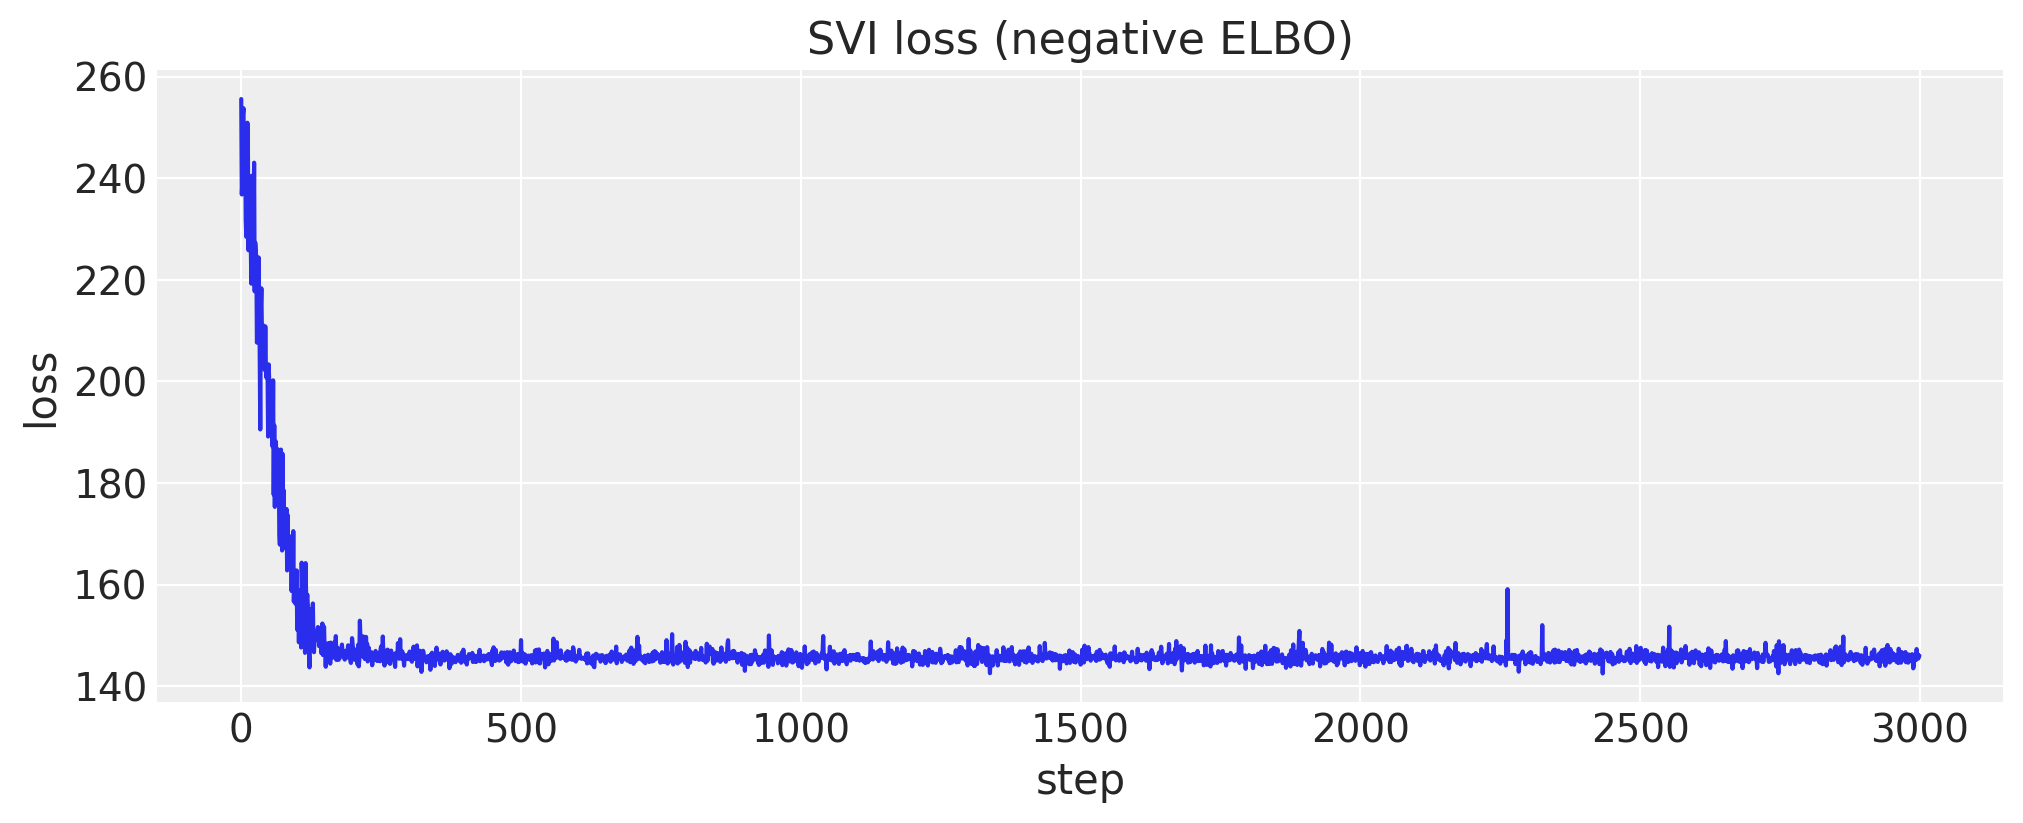

In [18]:
guide = AutoNormal(seasonal_level_smoothed)
svi = SVI(seasonal_level_smoothed, guide, Adam(step_size=0.01), Trace_ELBO())

rng_key, rng_subkey = random.split(rng_key)
start = time.perf_counter()
svi_result = svi.run(
    rng_subkey, 3_000, covariates_seasonal_train, train_seasonal, progress_bar=False
)
wall_svi = time.perf_counter() - start

rng_key, key_post, key_pred = random.split(rng_key, 3)
posterior_svi = draw_posterior(key_post, guide, svi_result.params, num_samples=2_000)
forecast_svi = forecast(
    key_pred, seasonal_level_smoothed, posterior_svi, train_seasonal, covariates_seasonal
)
print(f"SVI: {wall_svi:.1f} s, final loss {float(svi_result.losses[-1]):.2f}")
print(f"posterior mean of beta: {np.asarray(posterior_svi['beta']).mean(axis=0).round(2)}")
print(f"truth:                  {np.asarray(beta_true)}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.asarray(svi_result.losses), color="C0")
ax.set(title="SVI loss (negative ELBO)", xlabel="step", ylabel="loss");

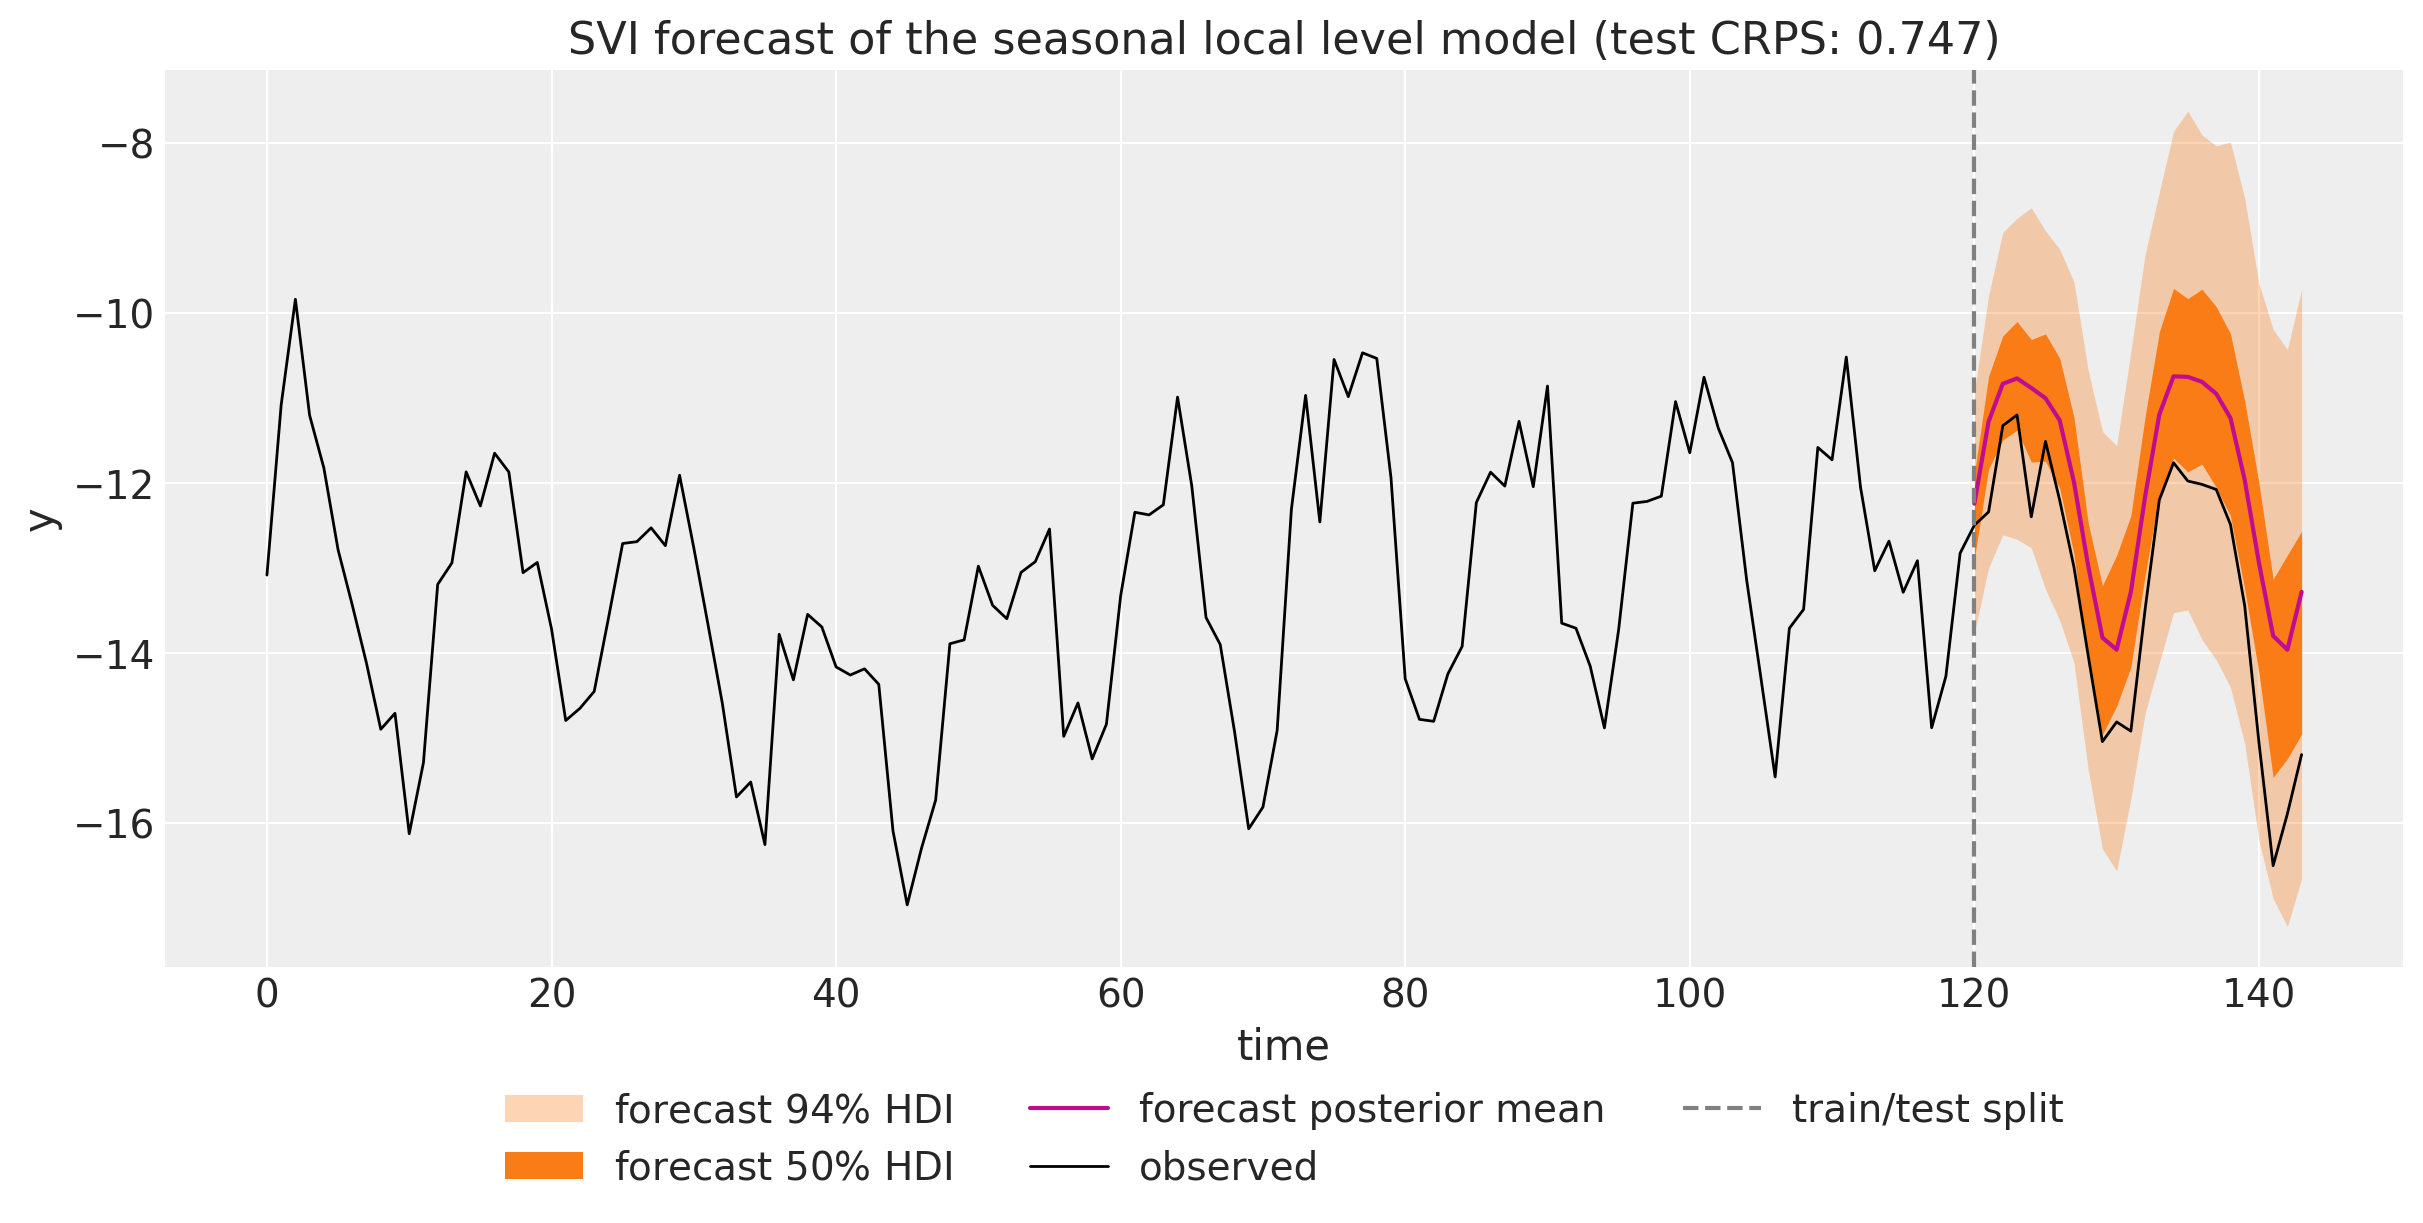

In [19]:
idata_forecast = predictions_to_datatree(
    forecast_svi, future_index.astype(float), ["y"], observed=test_seasonal
)
pc = az.plot_lm(
    idata_forecast,
    y="obs",
    x="t",
    plot_dim="time",
    ci_kind="hdi",
    ci_prob=hdi_probs,
    smooth=False,
    point_estimate="mean",
    visuals={
        "ci_band": {"color": "C1"},
        "observed_scatter": False,
        "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
    },
    figure_kwargs={"figsize": (12, 6)},
)
bands = pc.viz["ci_band"]["t"]
band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line = pc.viz["pe_line"]["t"].item()
pe_line.set_label("forecast posterior mean")
ax = pc.viz["figure"].item().axes[0]
(obs_line,) = ax.plot(
    time_index, np.asarray(y_seasonal[:, 0]), color="black", lw=1, label="observed"
)
split_line = ax.axvline(t_obs, color="gray", linestyle="--", label="train/test split")
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_line],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
crps_svi = eval_crps(forecast_svi, test_seasonal)
ax.set(
    title=f"SVI forecast of the seasonal local level model (test CRPS: {crps_svi:.3f})",
    xlabel="time",
    ylabel="y",
);

### Expanding-window backtest

A single split scores one held-out window. [`backtest`](https://juanitorduz.github.io/numpyro_forecast/reference/evaluate.backtest.html) moves the train/test boundary forward, refits from scratch and forecasts the next window, so every later part of the series is scored out of sample once. The loop delegates fitting and forecasting to two closures we write: `forecast_fn` fits the model with NUTS on the fold's training window and hands the draws to `forecast`, and `in_sample_fn` does the same and hands them to `predict_in_sample`, so that with `eval_train=True` every fold is also scored in sample. The `dynestyx` model needs no adapter for any of this: it is a `numpyro_forecast` model, and the closures are the same ones the other examples use. We size the folds at $12$ steps (`test_window=12`, `stride=12`) with the first $72$ observations seeding the initial training window, which gives six folds.

In [20]:
def fit_fold(
    rng_key: Array, model: ForecastModel, train_data: Array, train_covariates: Array
) -> dict:
    """NUTS on one fold: 2 chains of 500 warmup and 500 draws, flattened."""
    mcmc, _ = fit_nuts(
        rng_key, model, train_data, train_covariates, num_chains=2, num_warmup=500, num_samples=500
    )
    return mcmc.get_samples()


def forecast_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    full_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and forecast the test horizon."""
    key_fit, key_fc = random.split(rng_key)
    fold_posterior = fit_fold(key_fit, model, train_data, train_covariates)
    return forecast(
        key_fc, model, fold_posterior, train_data, full_covariates, batch_size=batch_size
    )


def in_sample_fn(
    rng_key: Array,
    model: ForecastModel,
    train_data: Array,
    train_covariates: Array,
    num_samples: int,
    *,
    batch_size: int | None = None,
) -> Array | np.ndarray:
    """Fit ``model`` on the training window with NUTS and score its in-sample fit."""
    key_fit, key_pred = random.split(rng_key)
    fold_posterior = fit_fold(key_fit, model, train_data, train_covariates)
    return predict_in_sample(
        key_pred, model, fold_posterior, train_covariates, batch_size=batch_size
    )


backtest_metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_94": partial(eval_coverage, alpha=0.94),
}

rng_key, rng_subkey = random.split(rng_key)
start = time.perf_counter()
results = backtest(
    rng_subkey,
    y_seasonal,
    covariates_seasonal,
    lambda: seasonal_level_smoothed,
    forecast_fn=forecast_fn,
    in_sample_fn=in_sample_fn,
    metrics=backtest_metrics,
    test_window=12,
    stride=12,
    min_train_window=72,
    num_samples=1_000,  # 2 chains x 500 draws, what fit_fold returns
    eval_train=True,
    keep_predictions=True,
)
print(f"backtest: {len(results)} folds in {time.perf_counter() - start:.1f} s")
results_to_dataframe(results).round(3)

backtest: 6 folds in 95.4 s


,t0,t1,t2,num_samples,walltime,metric_crps,metric_coverage_50,metric_coverage_94,train_metric_crps,train_metric_coverage_50,train_metric_coverage_94
0,0,72,84,1000,6.436,1.068,0.417,0.583,0.193,0.750,1.000
1,0,84,96,1000,8.020,0.403,0.833,1.000,0.204,0.738,1.000
2,0,96,108,1000,7.193,0.371,0.750,1.000,0.228,0.729,1.000
3,0,108,120,1000,8.234,0.467,0.500,1.000,0.231,0.704,1.000
4,0,120,132,1000,9.516,0.546,0.417,1.000,0.243,0.675,1.000
5,0,132,144,1000,9.684,0.334,0.833,1.000,0.244,0.652,0.992


Overlaying every fold's out-of-sample forecast on the series gives the rolling-origin view: each band starts where its training window ends, with the dashed lines marking the successive splits.

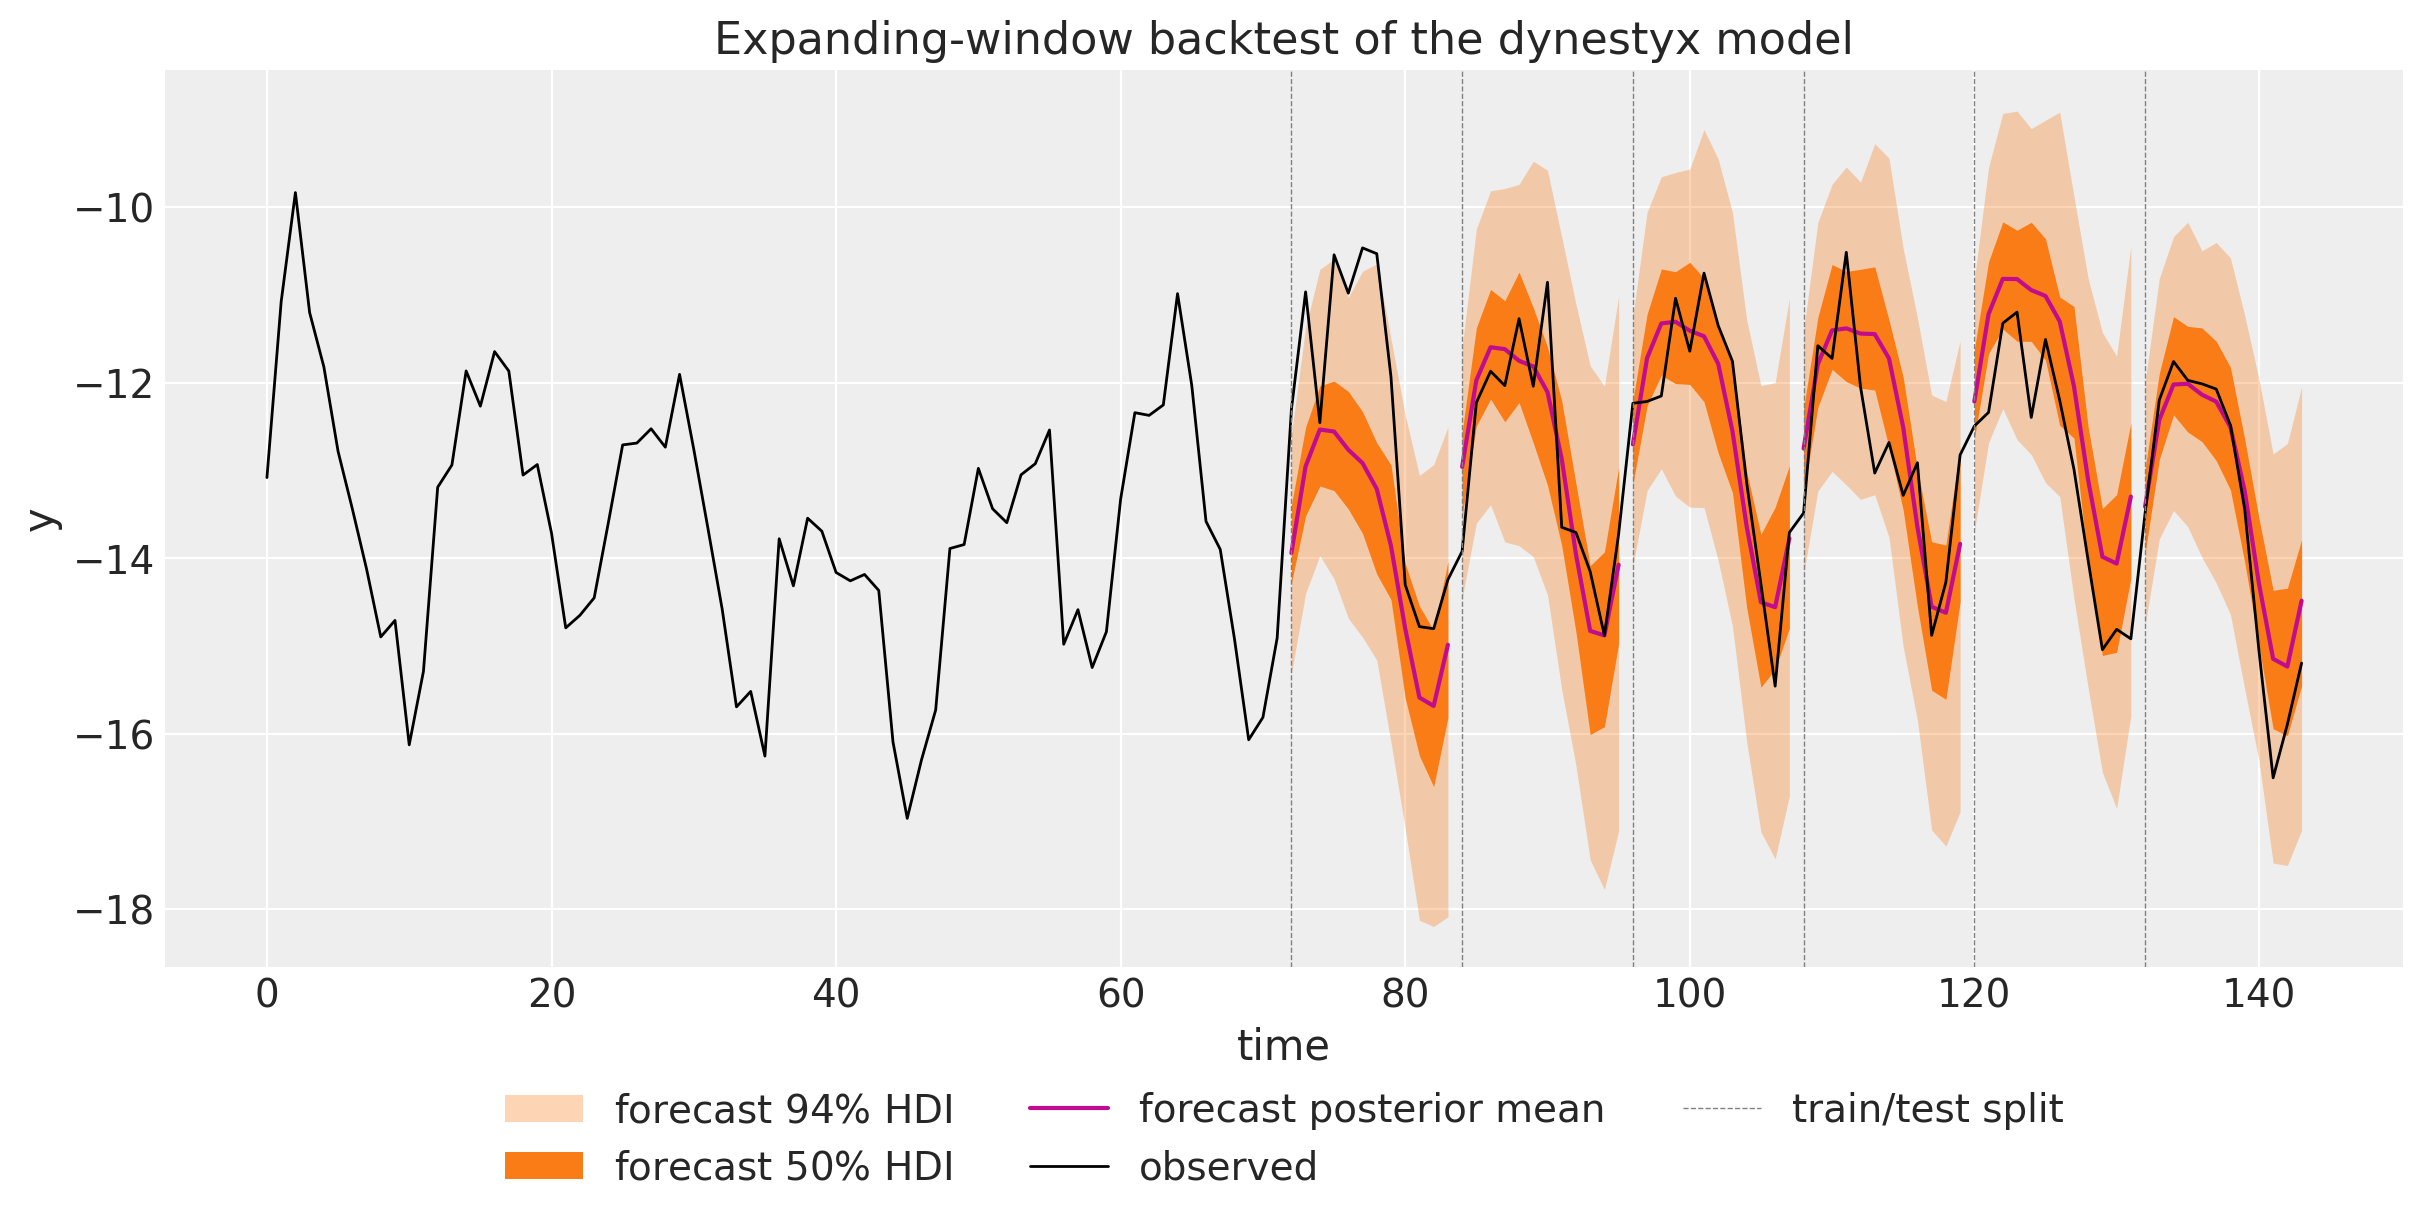

In [21]:
pc = None
for r in results:
    prediction = r.prediction
    if prediction is None:  # keep_predictions=True guarantees this never triggers
        continue
    fold_time = time_index[r.t1 : r.t2].astype(float)
    idata_fold = predictions_to_datatree(
        prediction, fold_time, ["y"], observed=y_seasonal[r.t1 : r.t2]
    )
    if pc is None:
        pc = az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
            },
            figure_kwargs={"figsize": (12, 6)},
        )
        bands = pc.viz["ci_band"]["t"]
        band_94, band_50 = bands.sel(prob=0.94).item(), bands.sel(prob=0.5).item()
        pe_line = pc.viz["pe_line"]["t"].item()
    else:
        az.plot_lm(
            idata_fold,
            y="obs",
            x="t",
            plot_dim="time",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=hdi_probs,
            smooth=False,
            point_estimate="mean",
            visuals={
                "ci_band": {"color": "C1"},
                "observed_scatter": False,
                "pe_line": {"color": "C3", "alpha": 1.0, "width": 1.5},
            },
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
band_94.set_label(hdi_label(0.94, prefix="forecast "))
band_50.set_label(hdi_label(0.5, prefix="forecast "))
pe_line.set_label("forecast posterior mean")
(obs_line,) = ax.plot(
    time_index, np.asarray(y_seasonal[:, 0]), color="black", lw=1, label="observed"
)
split_lines = [
    ax.axvline(r.t1, color="gray", ls="--", lw=0.5, label="train/test split") for r in results
]
ax.legend(
    handles=[band_94, band_50, pe_line, obs_line, split_lines[0]],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.1),
    ncol=3,
)
ax.set(title="Expanding-window backtest of the dynestyx model", xlabel="time", ylabel="y");

The per-fold scores summarize the picture. The in-sample CRPS is flat across folds and well below the out-of-sample CRPS, as it must be for a smoothing predictive that has seen the observations it scores. Out of sample, the first fold is the outlier: trained on $72$ points, six seasons, its level and seasonal coefficients are still poorly pinned down and its forecast sits low, with the widest band of all folds; from the second fold on the CRPS settles in a narrow range, and the empirical coverage of the central $50\%$ and $94\%$ intervals wobbles around the nominal levels, as expected with $12$ observations per fold (each observation moves the coverage by about $0.08$).

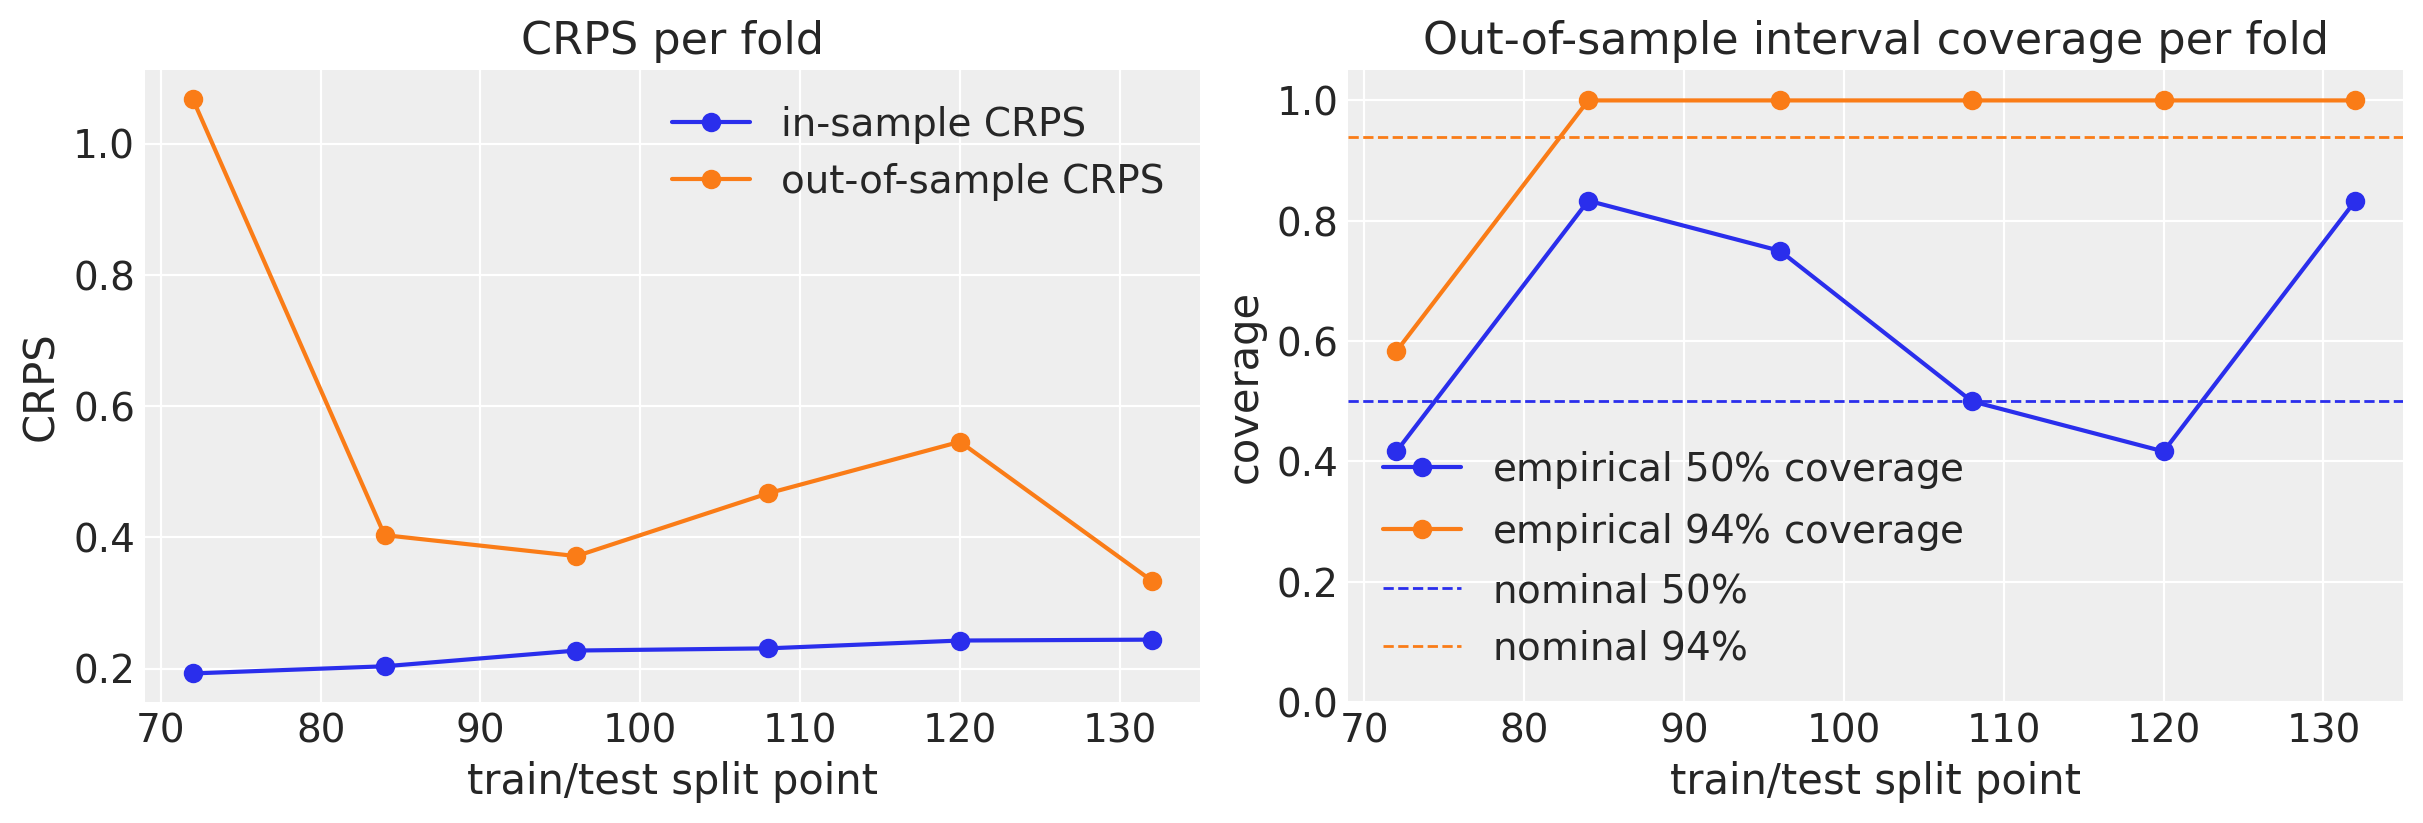

In [22]:
split_points = [r.t1 for r in results]
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 4), layout="constrained")
axes[0].plot(
    split_points,
    [r.train_metrics["crps"] for r in results],
    "o-",
    color="C0",
    label="in-sample CRPS",
)
axes[0].plot(
    split_points,
    [r.metrics["crps"] for r in results],
    "o-",
    color="C1",
    label="out-of-sample CRPS",
)
axes[0].legend()
axes[0].set(xlabel="train/test split point", ylabel="CRPS", title="CRPS per fold")
axes[1].plot(
    split_points,
    [r.metrics["coverage_50"] for r in results],
    "o-",
    color="C0",
    label=r"empirical $50\%$ coverage",
)
axes[1].plot(
    split_points,
    [r.metrics["coverage_94"] for r in results],
    "o-",
    color="C1",
    label=r"empirical $94\%$ coverage",
)
axes[1].axhline(0.5, color="C0", ls="--", lw=1, label=r"nominal $50\%$")
axes[1].axhline(0.94, color="C1", ls="--", lw=1, label=r"nominal $94\%$")
axes[1].legend(loc="lower left")
axes[1].set(
    xlabel="train/test split point",
    ylabel="coverage",
    title="Out-of-sample interval coverage per fold",
    ylim=(0, 1.05),
);

## Takeaways

- A `dynestyx` model becomes a `numpyro_forecast` model through one building block, and the `dynestyx` handler passed as its `conditioner` is the inference strategy: `Smoother` (or `Filter`) marginalizes the latent path, `LatentPathBuilder` samples it explicitly, and switching between them is a one-argument change. The block registers the horizon rollout as `"forecast"` and the in-sample predictive as `"obs"`, so `forecast`, `predict_in_sample`, `to_datatree`, `backtest` (in and out of sample) and the metrics work on it unchanged, under the same `jit` and `vmap` as for every other model.
- The observed window travels in the covariates, as it does for the package's `ssoe` models; that is what lets the drivers that call the model without data reach the observations a conditioned model needs. The block also owns two traps: the time grids are host-side constants for the smoother's rollout and jax arrays for the builder, and the rollout is anchored at the last observed step.
- On linear-Gaussian models the smoother is exact and costs the same per gradient as the filter, so it is the conditioner to reach for: the sampler explores the parameters only and needs a small fraction of the gradient evaluations of the direct model for a larger effective sample size, and the smoothing distribution gives the in-sample predictive for free. The explicit path through `dynestyx` sits in between and is the road to discretized continuous-time dynamics and to observation models with missing values. Beyond the linear-Gaussian case, the approximate filters and smoothers of `dynestyx` give pseudo-marginal inference for nonlinear and non-Gaussian dynamics.
- `dynestyx` predicts at or after the end of the window only, so the in-sample predictive comes from the conditioned distributions rather than from a rollout, and it is a per-step marginal (a functional of the whole path would need backward simulation). Prior predictive checks go through `dsx.simulate`. The `ssoe` family of the package with a latent level (exponential smoothing in innovations form) is already marginalized by its deterministic recursion and has no `dynestyx` counterpart; its members that are Markov in the observations (autoregressions) can be written with `DiracIdentityObservation` under a `LatentPathBuilder`, see the design document.

## References

- Waxman, D., Batenkov, D., Feser, J., Zane, A., Bingham, E., Marzouk, Y., & Levine, M. E. (2026). [*Dynestyx: A Probabilistic Programming Library for Dynamical Systems*](https://arxiv.org/abs/2606.16985).
- [`dynestyx` documentation](https://basisresearch.github.io/dynestyx/stable/), in particular the tutorials on [filtering and the marginal likelihood](https://basisresearch.github.io/dynestyx/stable/tutorials/gentle_intro/03_filtering_mll/) and on [discrete-time smoothing](https://basisresearch.github.io/dynestyx/stable/tutorials/gentle_intro/09_discrete_smoothing/).
- Durbin, J., & Koopman, S. J. (2012). *Time Series Analysis by State Space Methods*, 2nd edition. Oxford University Press.
- Särkkä, S., & Svensson, L. (2023). [*Bayesian Filtering and Smoothing*](https://users.aalto.fi/~ssarkka/pub/bfs_book_2023_online.pdf), 2nd edition. Cambridge University Press.
- [`DYNESTYX_INTEGRATION_DESIGN.md`](https://github.com/juanitorduz/numpyro_forecast/blob/main/DYNESTYX_INTEGRATION_DESIGN.md), the design document behind this notebook.